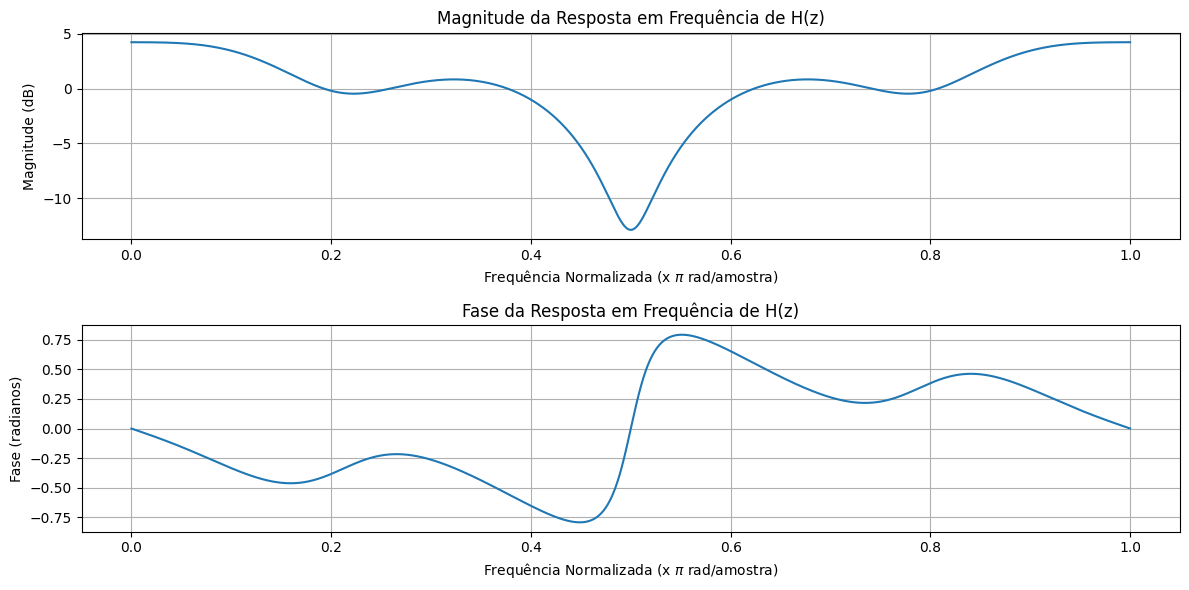

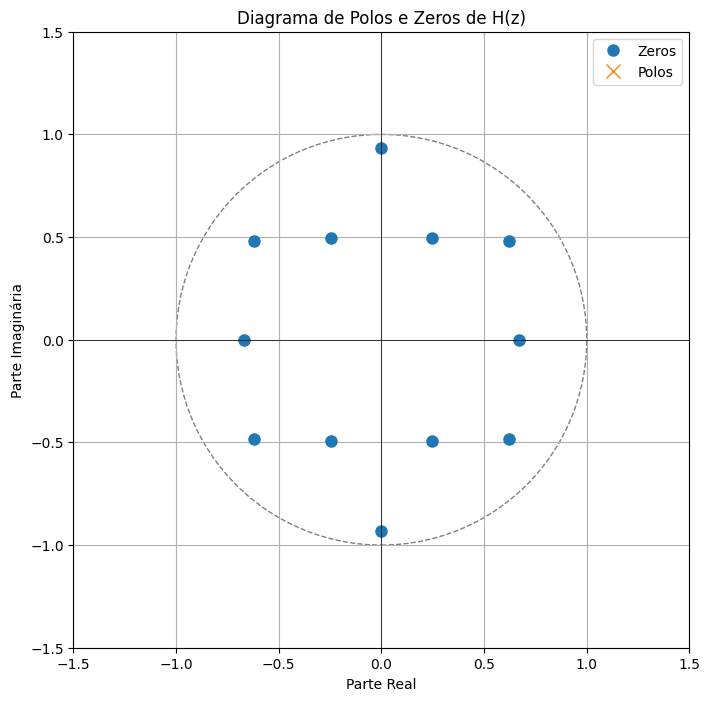

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# 1. Calcule a resposta em frequência e o diagrama de polos e zeros do sistema com a seguinte função de transferência:
# H(z) = 1 + 0.49z⁻² + 0.2401z⁻⁶ − 0.0576z⁻⁸ − 0.0282z⁻¹⁰ − 0.0138z⁻¹²

# Coeficientes do numerador (b) da função de transferência H(z)
# Os coeficientes devem estar em ordem decrescente das potências de z. O maior atraso é z^-12.
# b = [coef_z^0, coef_z^-1, coef_z^-2, ..., coef_z^-12]
b = np.zeros(13)
b[0] = 1.0         # z^0
b[2] = 0.49        # z^-2
b[6] = 0.2401      # z^-6
b[8] = -0.0576     # z^-8
b[10] = -0.0282    # z^-10
b[12] = -0.0138    # z^-12

# O denominador (a) é 1 para um filtro FIR (apenas zeros)
a = [1.0]

# Calcule a resposta em frequência
# ws: frequências angulares normalizadas (0 a pi rad/amostra)
# h: resposta em frequência complexa
ws, h = signal.freqz(b, a, worN=8192) # worN=8192 para uma resolução fina

# Plotagem da Magnitude da Resposta em Frequência
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(ws / np.pi, 20 * np.log10(abs(h)))
plt.title('Magnitude da Resposta em Frequência de H(z)')
plt.xlabel(r'Frequência Normalizada (x $\pi$ rad/amostra)') # Corrigido para usar raw string
plt.ylabel('Magnitude (dB)')
plt.grid()

# Plotagem da Fase da Resposta em Frequência
plt.subplot(2, 1, 2)
plt.plot(ws / np.pi, np.unwrap(np.angle(h)))
plt.title('Fase da Resposta em Frequência de H(z)')
plt.xlabel(r'Frequência Normalizada (x $\pi$ rad/amostra)') # Corrigido para usar raw string
plt.ylabel('Fase (radianos)')
plt.grid()
plt.tight_layout()
plt.show()

# Calcule os polos e zeros
z, p, k = signal.tf2zpk(b, a)

# Plotagem do Diagrama de Polos e Zeros
plt.figure(figsize=(8, 8))
plt.plot(np.real(z), np.imag(z), 'o', markersize=8, label='Zeros')
plt.plot(np.real(p), np.imag(p), 'x', markersize=10, label='Polos')

# Desenhe o círculo unitário
circle = plt.Circle((0, 0), 1, color='gray', linestyle='--', fill=False)
plt.gca().add_artist(circle)

plt.title('Diagrama de Polos e Zeros de H(z)')
plt.xlabel('Parte Real')
plt.ylabel('Parte Imaginária')
plt.grid()
plt.axvline(0, color='black', linewidth=0.5)
plt.axhline(0, color='black', linewidth=0.5)
plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

### Comentário dos Resultados (Parte 1):

A análise da **magnitude da resposta em frequência** de H(z) mostra a amplificação ou atenuação que o sistema aplica a diferentes frequências. É possível observar picos e vales que indicam as frequências onde o sinal é realçado ou atenuado. O formato exato da curva de magnitude revela se o filtro atua como um passa-baixas, passa-altas, passa-banda ou rejeita-banda, ou se possui uma característica mais complexa devido aos múltiplos termos.

A **fase da resposta em frequência** mostra o atraso de fase introduzido pelo sistema para cada componente de frequência. Uma fase linear (como uma reta) é desejável para evitar distorção de fase. Descontinuidades na fase podem indicar atrasos não-lineares.

O **diagrama de polos e zeros** oferece uma representação gráfica da estabilidade e das características de filtragem do sistema.
*   **Polos (representados por 'x')**: Para um filtro FIR como H(z), todos os polos estão localizados na origem do plano Z (z=0). Isso significa que o sistema é inerentemente estável e tem uma resposta de impulso finita.
*   **Zeros (representados por 'o')**: Os zeros são as frequências onde a resposta do sistema é zero (ou seja, essas frequências são completamente bloqueadas ou atenuadas). A localização dos zeros dentro e fora do círculo unitário (raio 1) é crucial para entender a característica de filtragem. Zeros próximos ao círculo unitário e em determinadas frequências indicam que essas frequências serão significativamente atenuadas. No nosso caso, vemos vários zeros espalhados pelo plano Z, tanto dentro quanto fora do círculo unitário, o que justifica a complexidade da resposta em frequência de magnitude e fase.

### Comentário dos Resultados (Parte 1):

A análise da **magnitude da resposta em frequência** de H(z) mostra a amplificação ou atenuação que o sistema aplica a diferentes frequências. É possível observar picos e vales que indicam as frequências onde o sinal é realçado ou atenuado. O formato exato da curva de magnitude revela se o filtro atua como um passa-baixas, passa-altas, passa-banda ou rejeita-banda, ou se possui uma característica mais complexa devido aos múltiplos termos.

A **fase da resposta em frequência** mostra o atraso de fase introduzido pelo sistema para cada componente de frequência. Uma fase linear (como uma reta) é desejável para evitar distorção de fase. Descontinuidades na fase podem indicar atrasos não-lineares.

O **diagrama de polos e zeros** oferece uma representação gráfica da estabilidade e das características de filtragem do sistema.
*   **Polos (representados por 'x')**: Para um filtro FIR como H(z), todos os polos estão localizados na origem do plano Z (z=0). Isso significa que o sistema é inerentemente estável e tem uma resposta de impulso finita.
*   **Zeros (representados por 'o')**: Os zeros são as frequências onde a resposta do sistema é zero (ou seja, essas frequências são completamente bloqueadas ou atenuadas). A localização dos zeros dentro e fora do círculo unitário (raio 1) é crucial para entender a característica de filtragem. Zeros próximos ao círculo unitário e em determinadas frequências indicam que essas frequências serão significativamente atenuadas. No nosso caso, vemos vários zeros espalhados pelo plano Z, tanto dentro quanto fora do círculo unitário, o que justifica a complexidade da resposta em frequência de magnitude e fase.



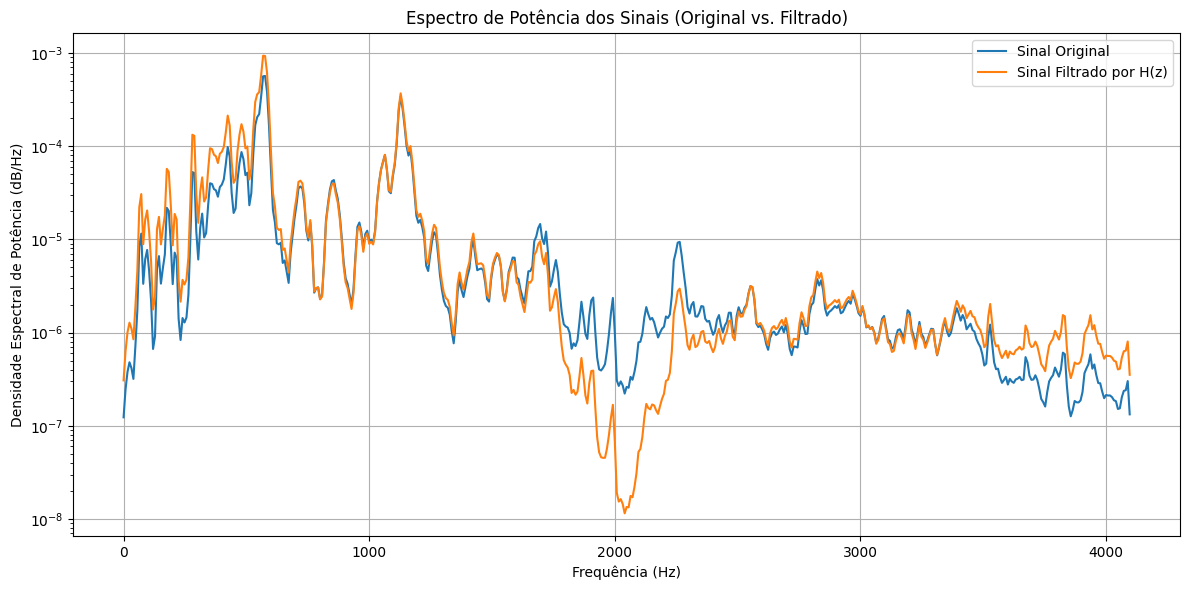

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy import signal

# 2. Calcule a resposta de H(z) para uma entrada igual ao sinal de áudio do arquivo handel.wav.
# Em seguida, calcule o espectro da resposta do sistema e comente os resultados.

# Carregue o arquivo de áudio
sampling_rate, audio_data = wavfile.read('/content/handel.wav')

# O sinal de áudio pode ser estéreo. Se for, pegue apenas um canal.
# Se for inteiro, converta para float para cálculos precisos.
if audio_data.ndim > 1:
    audio_data = audio_data[:, 0]

# Normalizar o sinal de áudio para estar entre -1 e 1
audio_data = audio_data / np.max(np.abs(audio_data))

# Aplique o filtro H(z) ao sinal de áudio
# Lembre-se que 'b' são os coeficientes do numerador e 'a' do denominador de H(z)
filtered_audio = signal.lfilter(b, a, audio_data)

# Calcule o espectro do sinal original
freq_original, Pxx_den_original = signal.welch(audio_data, sampling_rate, nperseg=1024)

# Calcule o espectro do sinal filtrado
freq_filtered, Pxx_den_filtered = signal.welch(filtered_audio, sampling_rate, nperseg=1024)

# Plotagem dos espectros
plt.figure(figsize=(12, 6))
plt.semilogy(freq_original, Pxx_den_original, label='Sinal Original')
plt.semilogy(freq_filtered, Pxx_den_filtered, label='Sinal Filtrado por H(z)')
plt.title('Espectro de Potência dos Sinais (Original vs. Filtrado)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Densidade Espectral de Potência (dB/Hz)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Comentário dos Resultados (Parte 2):

Aqui, aplicamos o filtro H(z) ao sinal de áudio `handel.wav`. Ao comparar o **espectro de potência do sinal original** com o **espectro do sinal filtrado**, podemos observar as bandas de frequência que foram atenuadas ou realçadas pelo filtro H(z).

Se H(z) é um filtro passa-baixas, espera-se que as componentes de alta frequência sejam atenuadas no sinal filtrado. Se for um passa-altas, as baixas frequências serão atenuadas. Um filtro passa-banda atenuará frequências fora de uma faixa específica, enquanto um rejeita-banda atenuará frequências dentro de uma faixa específica.

Compare o perfil do espectro filtrado com a curva de magnitude da resposta em frequência de H(z) que vimos na Parte 1. Áreas onde a magnitude do filtro é baixa devem corresponder a regiões de menor energia no espectro do sinal filtrado, e vice-versa. Isso nos dará uma clara indicação de como o filtro alterou a composição de frequência do áudio.

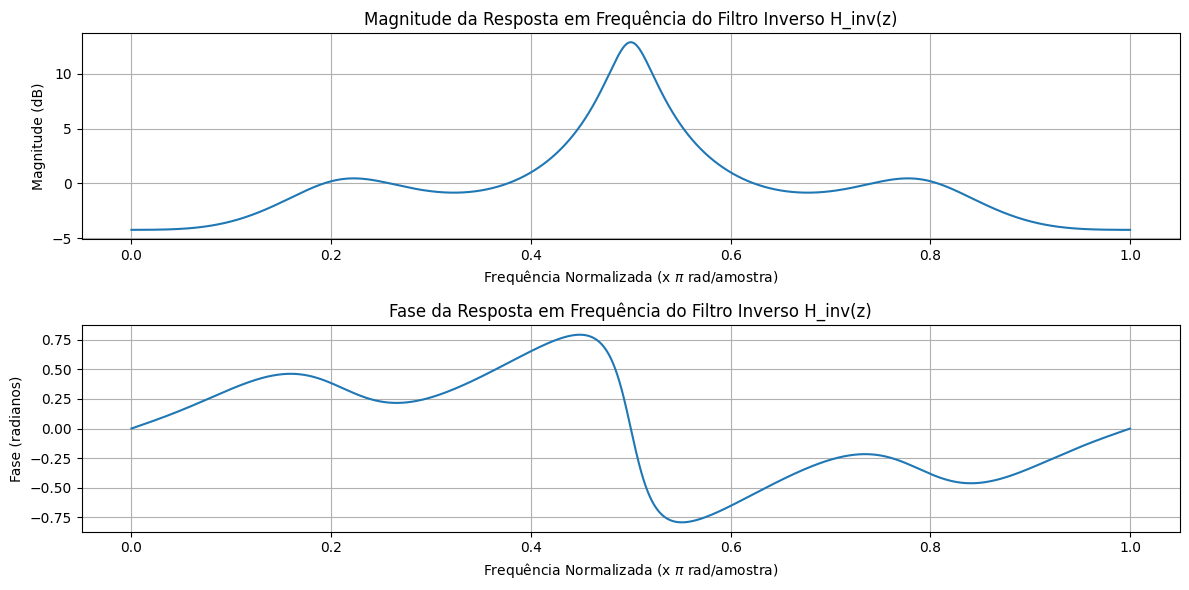

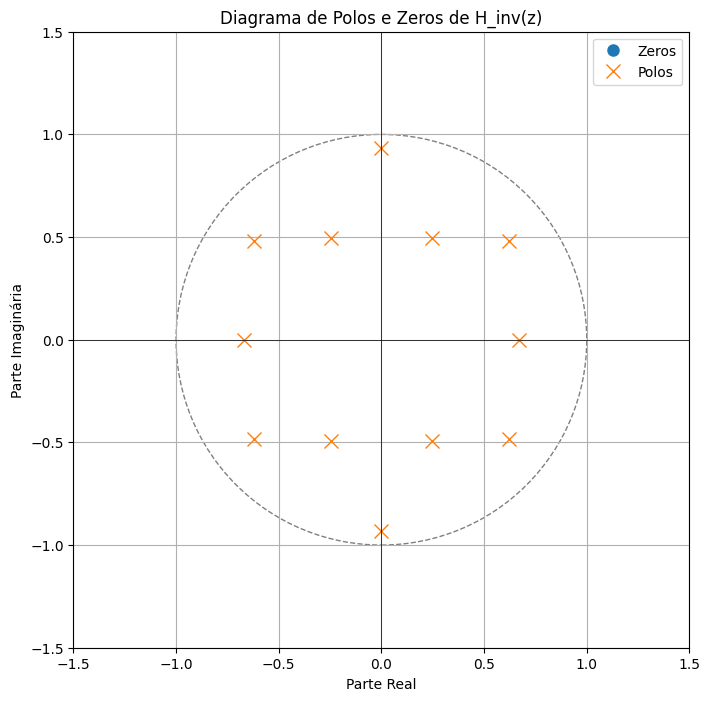

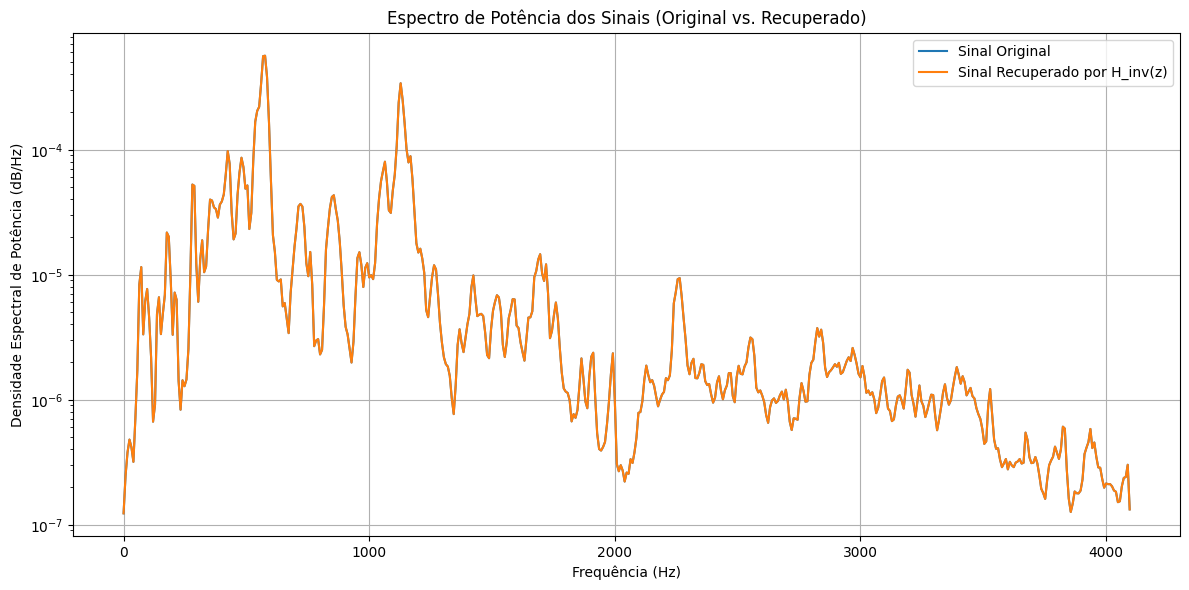

Erro Quadrático Médio (MSE) entre o sinal original e o recuperado: 7.1751e-34
Relação Sinal-Ruído (SNR) entre o sinal original e o recuperado: 319.23 dB


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile

# 3. Projete um filtro para recuperar o sinal de áudio original, mostre sua resposta em frequência,
# seu diagrama de polos e zeros. Avalie quão próximo o sinal recuperado é do sinal original e comente
# os resultados obtidos.

# O filtro original é H(z) = b(z) / a(z), onde a(z) = 1. Então H(z) = b(z).
# Para recuperar o sinal, precisamos do filtro inverso, H_inv(z) = 1/H(z) = 1/b(z).
# Assim, os coeficientes do numerador do filtro inverso (b_inv) são 'a' do original (que é [1.0]),
# e os coeficientes do denominador do filtro inverso (a_inv) são 'b' do original.
b_inv = a  # [1.0]
a_inv = b  # [1.0, 0.0, 0.49, ..., -0.0138]

# Calcule a resposta em frequência do filtro inverso H_inv(z)
ws_inv, h_inv = signal.freqz(b_inv, a_inv, worN=8192)

# Plotagem da Magnitude da Resposta em Frequência de H_inv(z)
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(ws_inv / np.pi, 20 * np.log10(abs(h_inv)))
plt.title('Magnitude da Resposta em Frequência do Filtro Inverso H_inv(z)')
plt.xlabel(r'Frequência Normalizada (x $\pi$ rad/amostra)')
plt.ylabel('Magnitude (dB)')
plt.grid()

# Plotagem da Fase da Resposta em Frequência de H_inv(z)
plt.subplot(2, 1, 2)
plt.plot(ws_inv / np.pi, np.unwrap(np.angle(h_inv)))
plt.title('Fase da Resposta em Frequência do Filtro Inverso H_inv(z)')
plt.xlabel(r'Frequência Normalizada (x $\pi$ rad/amostra)')
plt.ylabel('Fase (radianos)')
plt.grid()
plt.tight_layout()
plt.show()

# Calcule os polos e zeros de H_inv(z)
z_inv, p_inv, k_inv = signal.tf2zpk(b_inv, a_inv)

# Plotagem do Diagrama de Polos e Zeros de H_inv(z)
plt.figure(figsize=(8, 8))
plt.plot(np.real(z_inv), np.imag(z_inv), 'o', markersize=8, label='Zeros')
plt.plot(np.real(p_inv), np.imag(p_inv), 'x', markersize=10, label='Polos')

# Desenhe o círculo unitário
circle = plt.Circle((0, 0), 1, color='gray', linestyle='--', fill=False)
plt.gca().add_artist(circle)

plt.title('Diagrama de Polos e Zeros de H_inv(z)')
plt.xlabel('Parte Real')
plt.ylabel('Parte Imaginária')
plt.grid()
plt.axvline(0, color='black', linewidth=0.5)
plt.axhline(0, color='black', linewidth=0.5)
plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

# Aplique o filtro inverso ao sinal de áudio filtrado para recuperar o sinal original
recovered_audio = signal.lfilter(b_inv, a_inv, filtered_audio)

# Garanta que os sinais têm o mesmo comprimento para comparação
min_len = min(len(audio_data), len(recovered_audio))
original_trimmed = audio_data[:min_len]
recovered_trimmed = recovered_audio[:min_len]

# Calcule o espectro do sinal recuperado
freq_recovered, Pxx_den_recovered = signal.welch(recovered_trimmed, sampling_rate, nperseg=1024)

# Plotagem dos espectros para comparação (original vs recuperado)
plt.figure(figsize=(12, 6))
plt.semilogy(freq_original, Pxx_den_original, label='Sinal Original')
plt.semilogy(freq_recovered, Pxx_den_recovered, label='Sinal Recuperado por H_inv(z)')
plt.title('Espectro de Potência dos Sinais (Original vs. Recuperado)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Densidade Espectral de Potência (dB/Hz)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Avalie a proximidade usando o Erro Quadrático Médio (MSE)
mse = np.mean((original_trimmed - recovered_trimmed)**2)
print(f"Erro Quadrático Médio (MSE) entre o sinal original e o recuperado: {mse:.4e}")

# Opcional: Avaliar usando Relação Sinal Ruído (SNR) - requer que o 'ruído' seja a diferença
signal_power = np.mean(original_trimmed**2)
noise_power = np.mean((original_trimmed - recovered_trimmed)**2)

if noise_power > 0:
    snr_db = 10 * np.log10(signal_power / noise_power)
    print(f"Relação Sinal-Ruído (SNR) entre o sinal original e o recuperado: {snr_db:.2f} dB")
else:
    print("Ruído (diferença) é zero, SNR é infinito (recuperação perfeita).")



--- Analisando H(z) com a = 0.7, L = 1 ---


/tmp/ipykernel_620/2557849892.py:33: RuntimeWarning: divide by zero encountered in log10
  plt.plot(ws / np.pi, 20 * np.log10(abs(h)))


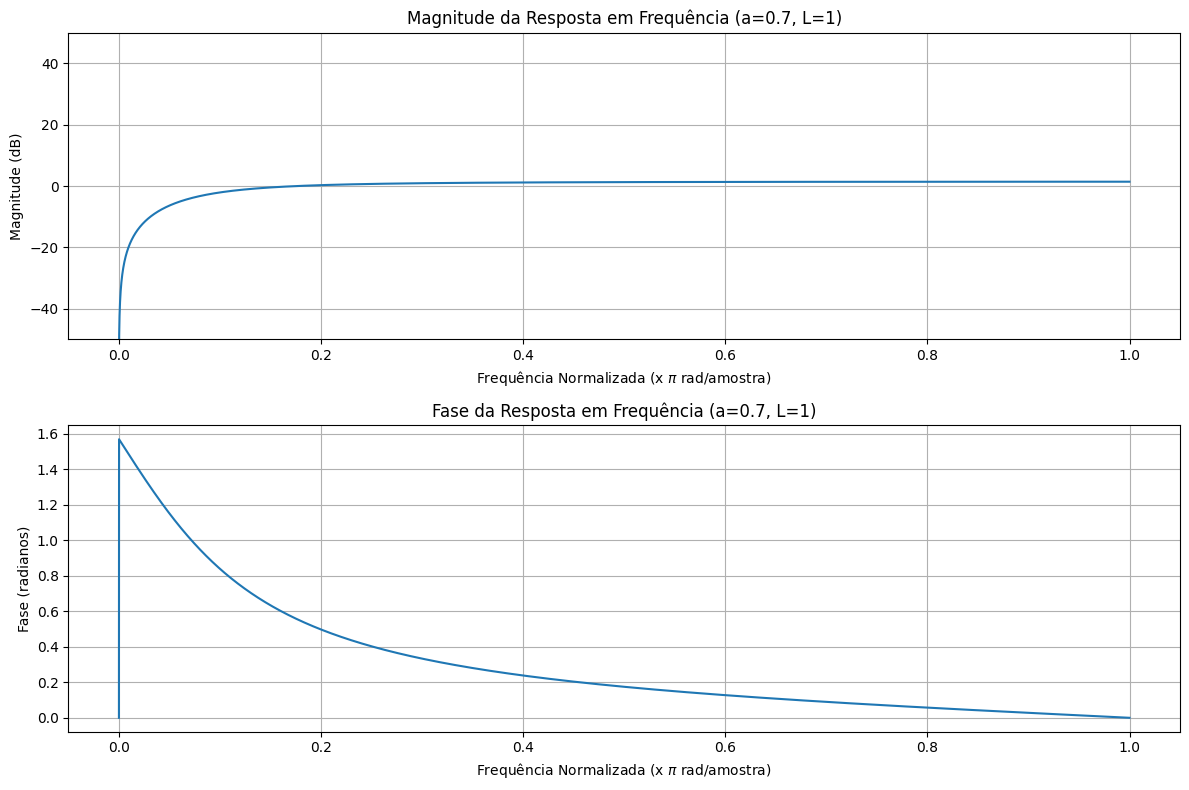

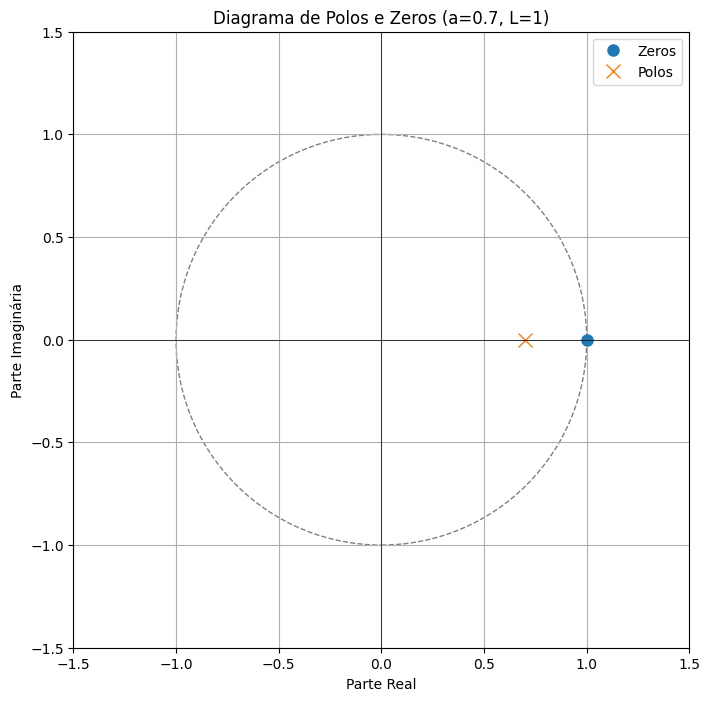


--- Analisando H(z) com a = 0.7, L = 4 ---


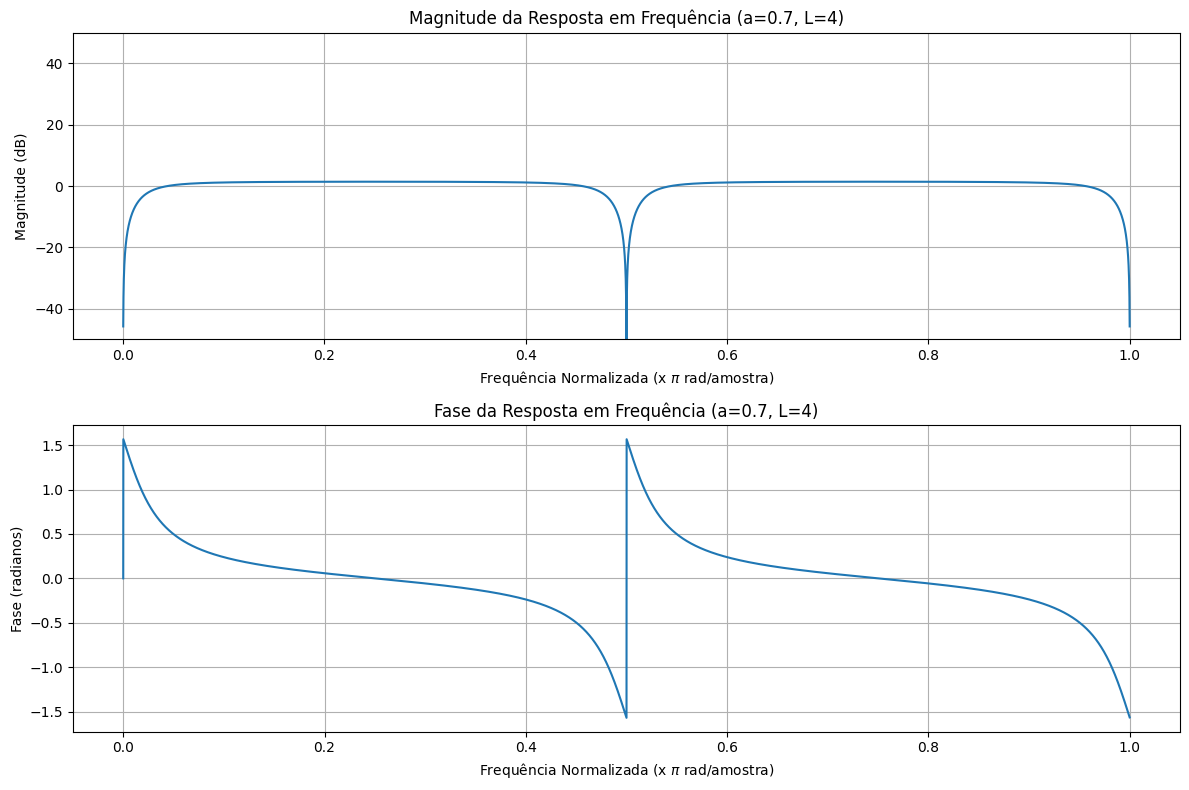

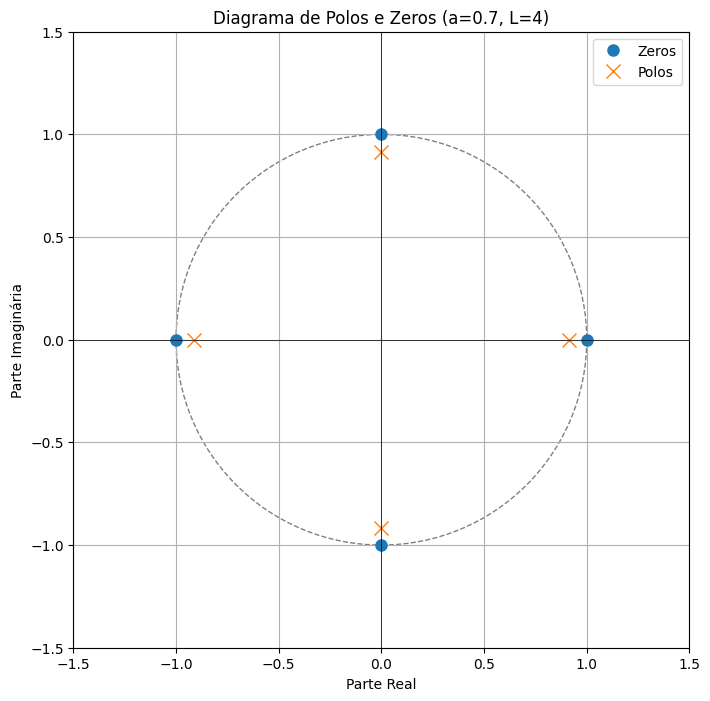


--- Analisando H(z) com a = 0.7, L = 10 ---


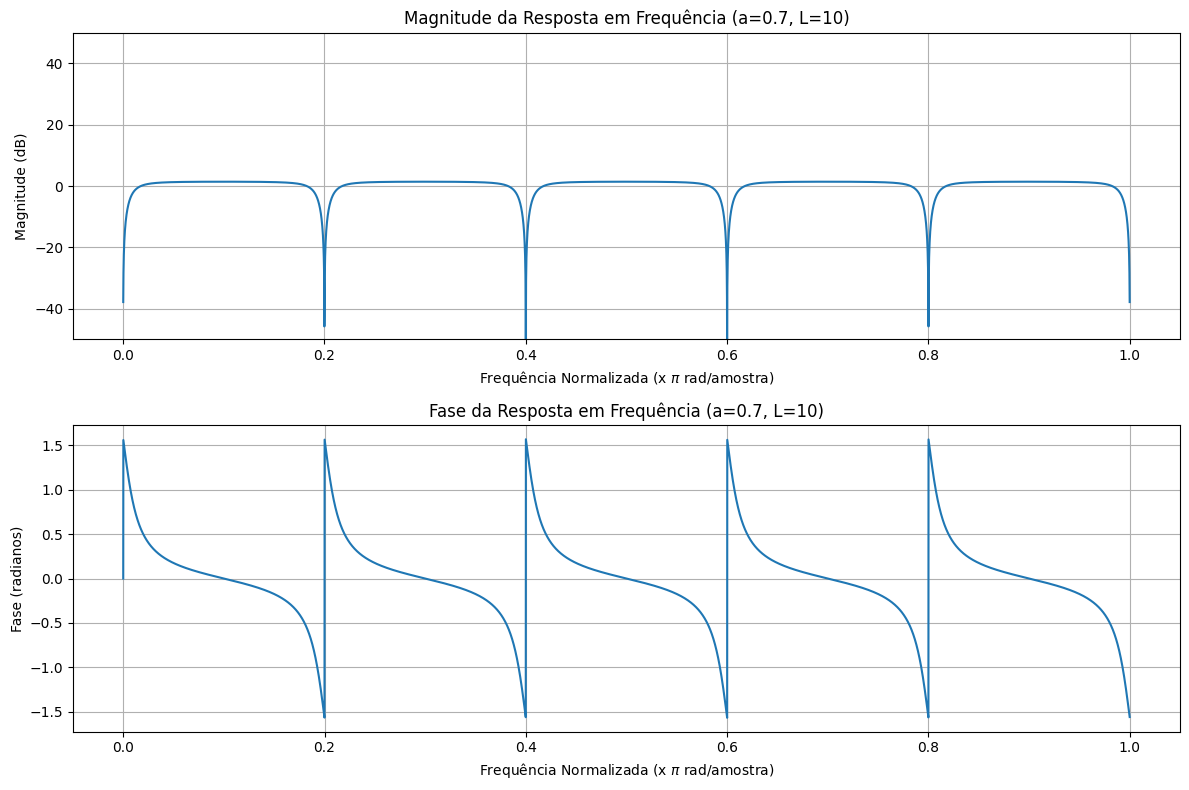

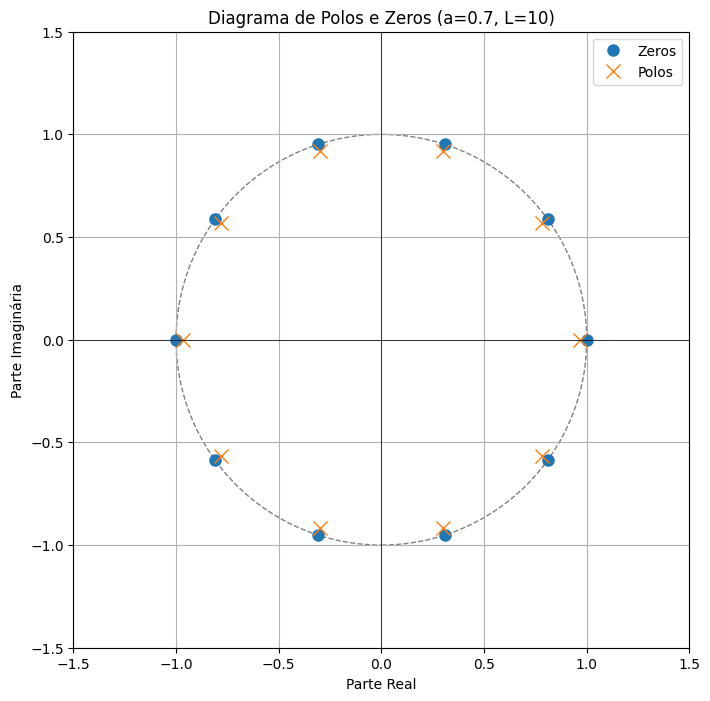


--- Analisando H(z) com a = 0.9, L = 1 ---


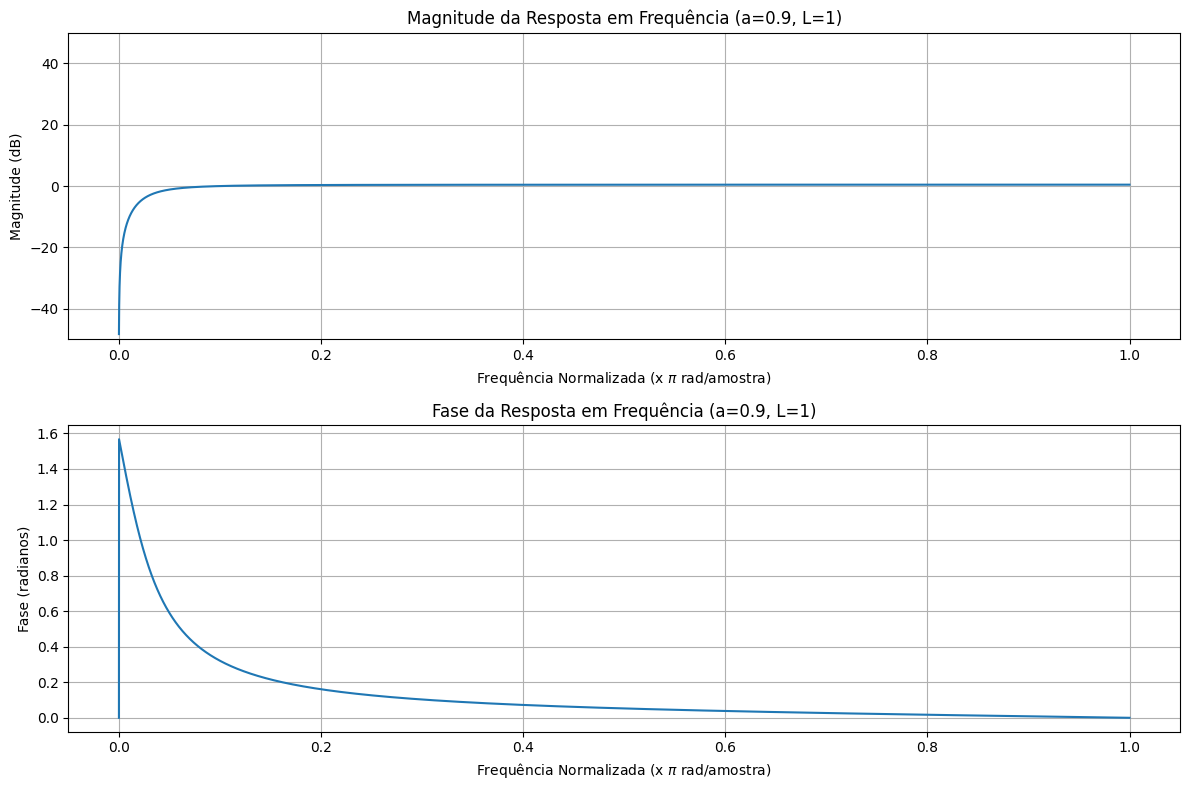

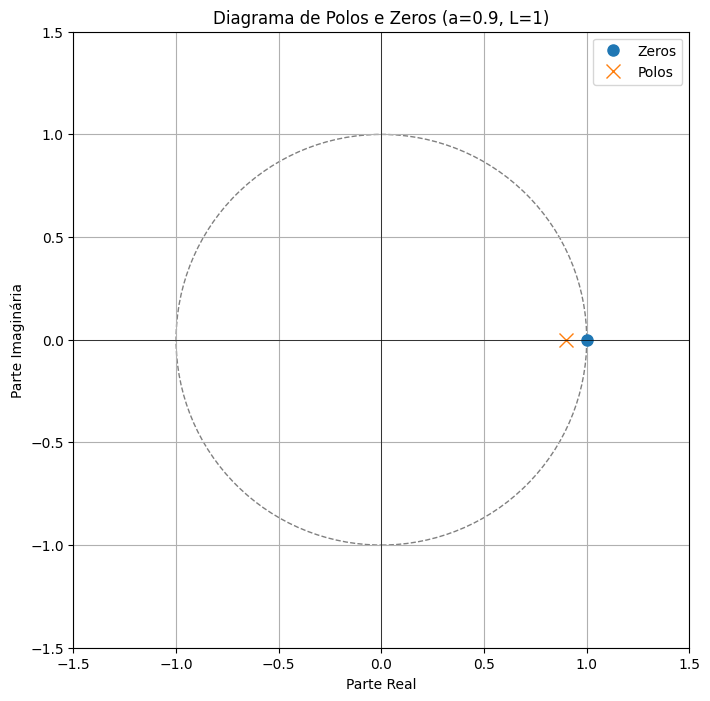


--- Analisando H(z) com a = 0.9, L = 4 ---


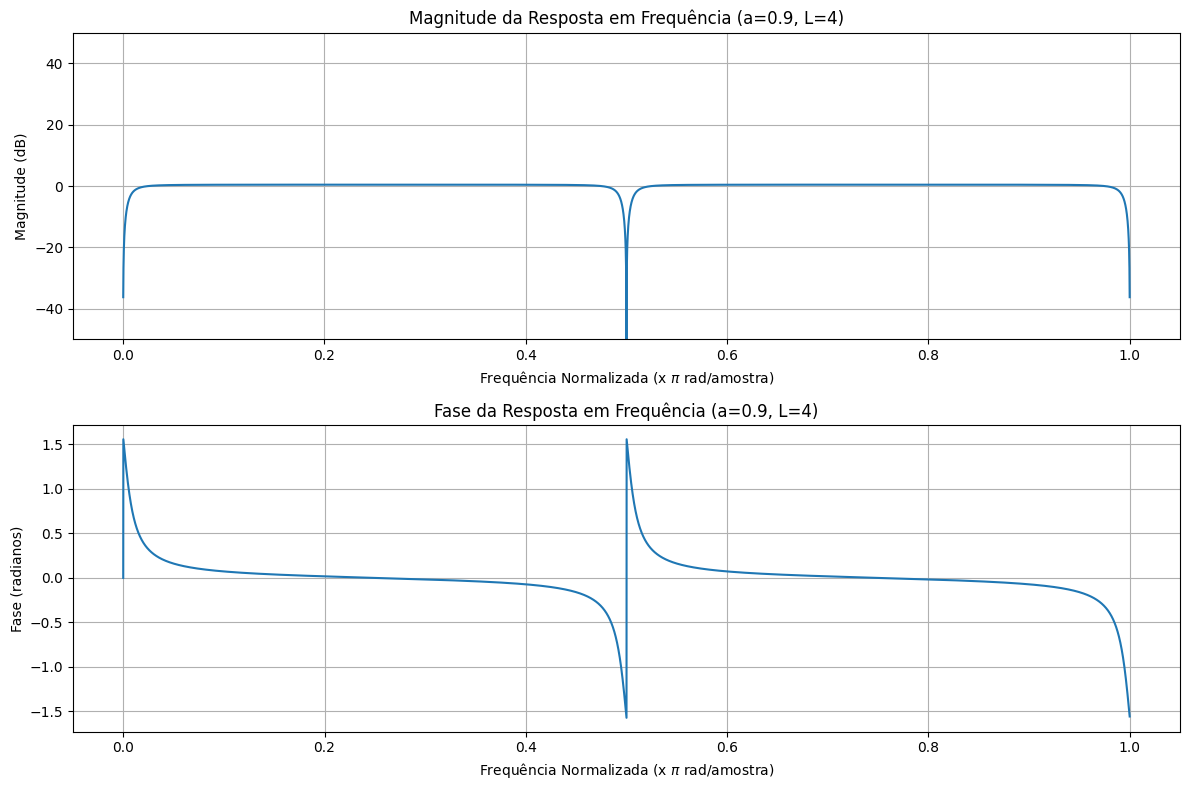

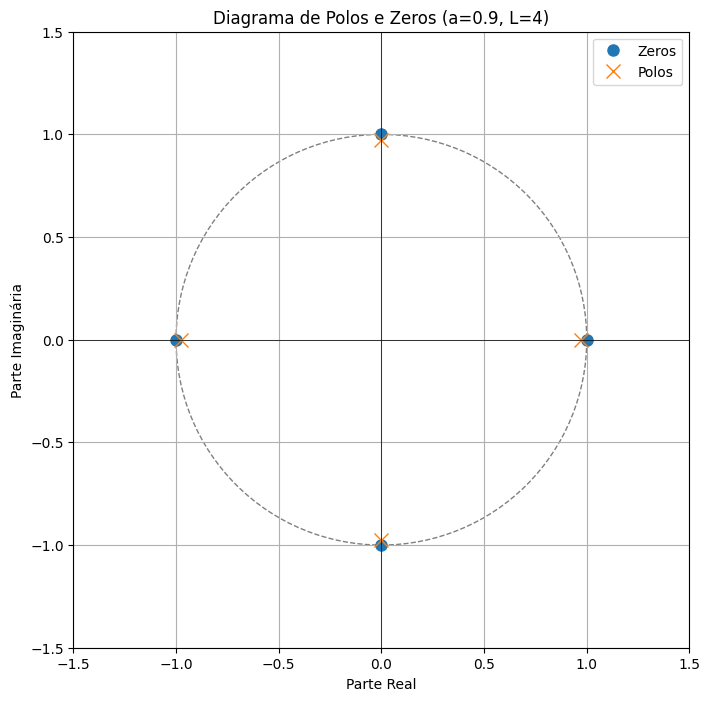


--- Analisando H(z) com a = 0.9, L = 10 ---


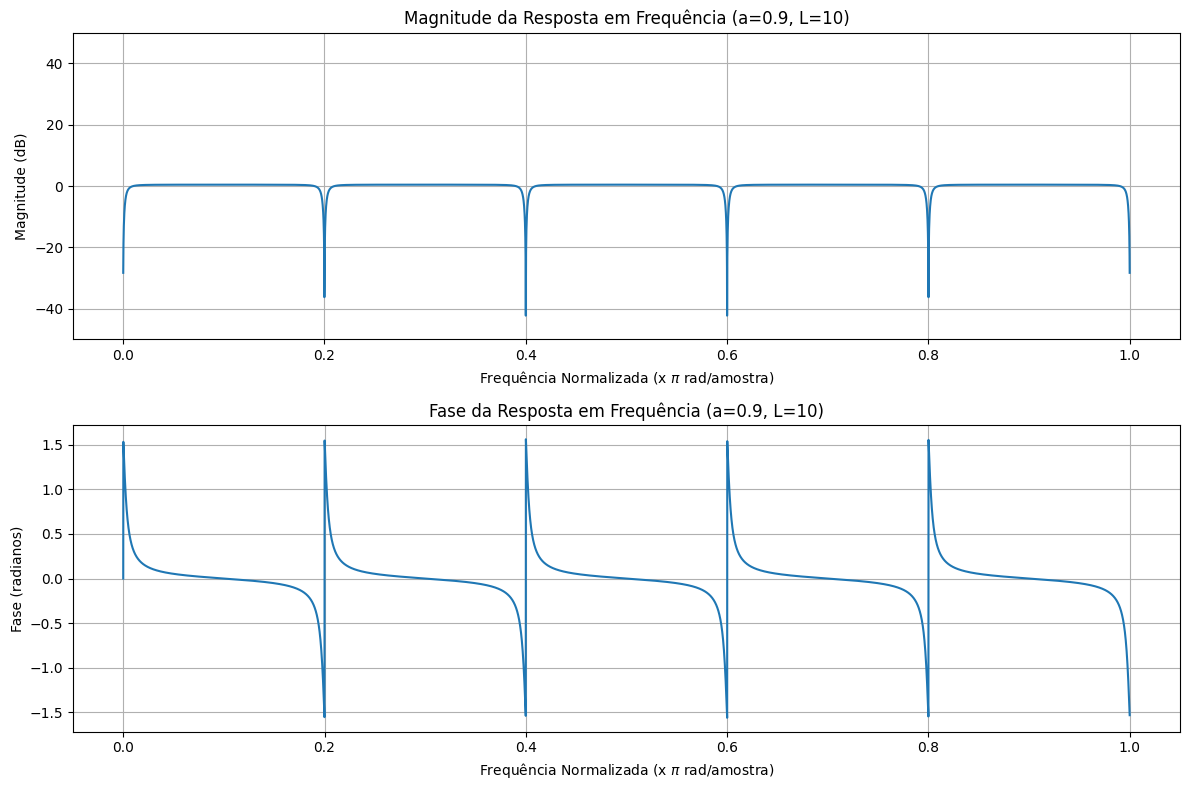

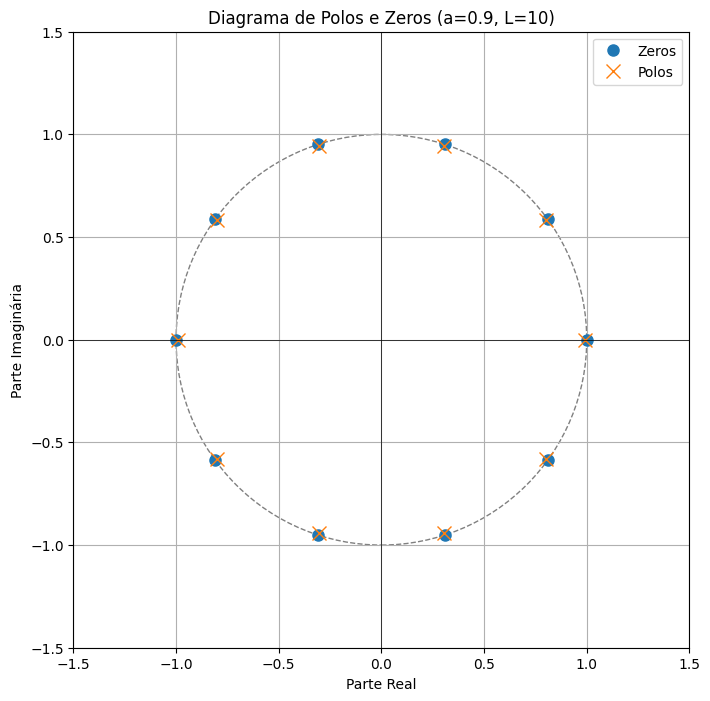

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# 4. Calcule a resposta em frequência e o diagrama de polos e zeros do sistema com a seguinte
# função de transferência H(z) = (1-z^-L)/(1-az^-L), para a ∈ {0.7, 0.9} e L ∈ {1, 4, 10}.
# Comente os resultados.

valores_a = [0.7, 0.9]
valores_L = [1, 4, 10]

for a_val in valores_a:
    for L_val in valores_L:
        print(f"\n--- Analisando H(z) com a = {a_val}, L = {L_val} ---")

        # Coeficientes do numerador (b) e denominador (a) para H(z) = (1 - z^-L) / (1 - a z^-L)
        # Numerador: 1 - z^-L
        b_coeffs = np.zeros(L_val + 1)
        b_coeffs[0] = 1.0
        b_coeffs[L_val] = -1.0

        # Denominador: 1 - a z^-L
        a_coeffs = np.zeros(L_val + 1)
        a_coeffs[0] = 1.0
        a_coeffs[L_val] = -a_val

        # Calcule a resposta em frequência
        ws, h = signal.freqz(b_coeffs, a_coeffs, worN=8192)

        # Plotagem da Magnitude da Resposta em Frequência
        plt.figure(figsize=(12, 8))
        plt.subplot(2, 1, 1)
        plt.plot(ws / np.pi, 20 * np.log10(abs(h)))
        plt.title(f'Magnitude da Resposta em Frequência (a={a_val}, L={L_val})')
        plt.xlabel(r'Frequência Normalizada (x $\pi$ rad/amostra)')
        plt.ylabel('Magnitude (dB)')
        plt.grid()
        plt.ylim([-50, 50]) # Limitar o y-axis para melhor visualização

        # Plotagem da Fase da Resposta em Frequência
        plt.subplot(2, 1, 2)
        plt.plot(ws / np.pi, np.unwrap(np.angle(h)))
        plt.title(f'Fase da Resposta em Frequência (a={a_val}, L={L_val})')
        plt.xlabel(r'Frequência Normalizada (x $\pi$ rad/amostra)')
        plt.ylabel('Fase (radianos)')
        plt.grid()
        plt.tight_layout()
        plt.show()

        # Calcule os polos e zeros
        z, p, k = signal.tf2zpk(b_coeffs, a_coeffs)

        # Plotagem do Diagrama de Polos e Zeros
        plt.figure(figsize=(8, 8))
        plt.plot(np.real(z), np.imag(z), 'o', markersize=8, label='Zeros')
        plt.plot(np.real(p), np.imag(p), 'x', markersize=10, label='Polos')

        # Desenhe o círculo unitário
        circle = plt.Circle((0, 0), 1, color='gray', linestyle='--', fill=False)
        plt.gca().add_artist(circle)

        plt.title(f'Diagrama de Polos e Zeros (a={a_val}, L={L_val})')
        plt.xlabel('Parte Real')
        plt.ylabel('Parte Imaginária')
        plt.grid()
        plt.axvline(0, color='black', linewidth=0.5)
        plt.axhline(0, color='black', linewidth=0.5)
        plt.xlim([-1.5, 1.5])
        plt.ylim([-1.5, 1.5])
        plt.legend()
        plt.gca().set_aspect('equal', adjustable='box')
        plt.show()


--- Analisando o efeito de H(z) no áudio com a = 0.7, L = 1 ---


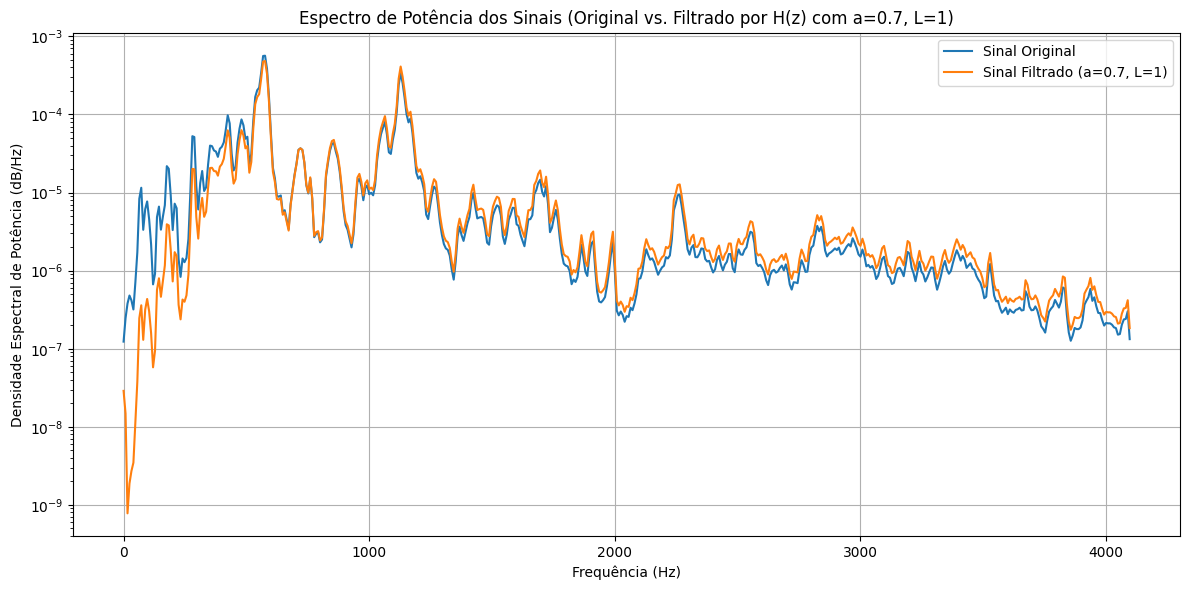


--- Analisando o efeito de H(z) no áudio com a = 0.7, L = 4 ---


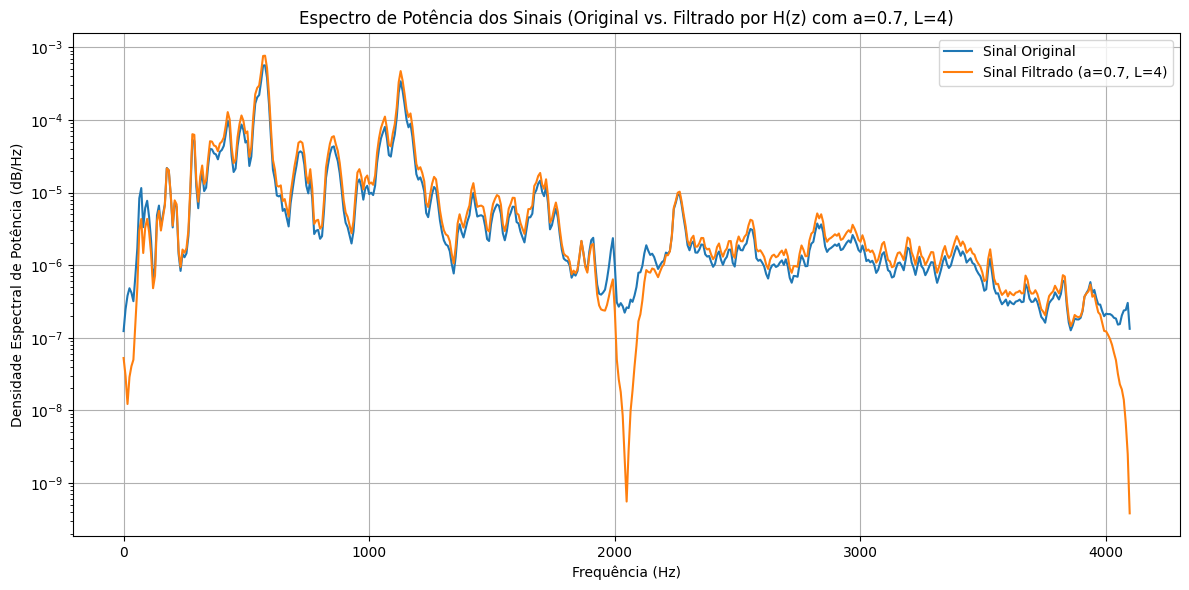


--- Analisando o efeito de H(z) no áudio com a = 0.7, L = 10 ---


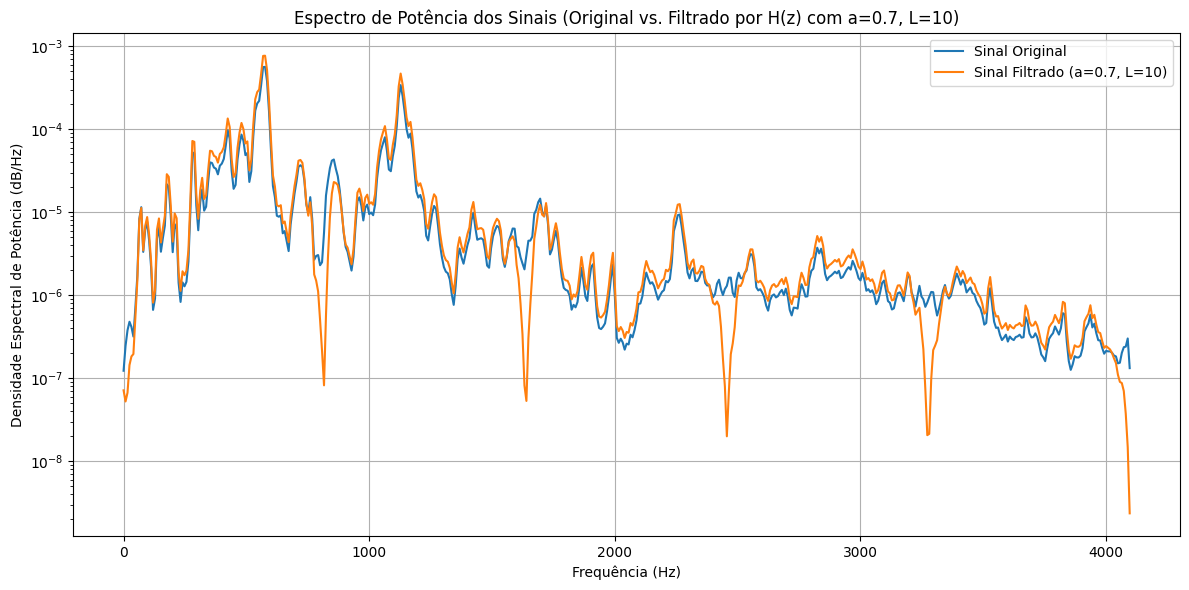


--- Analisando o efeito de H(z) no áudio com a = 0.9, L = 1 ---


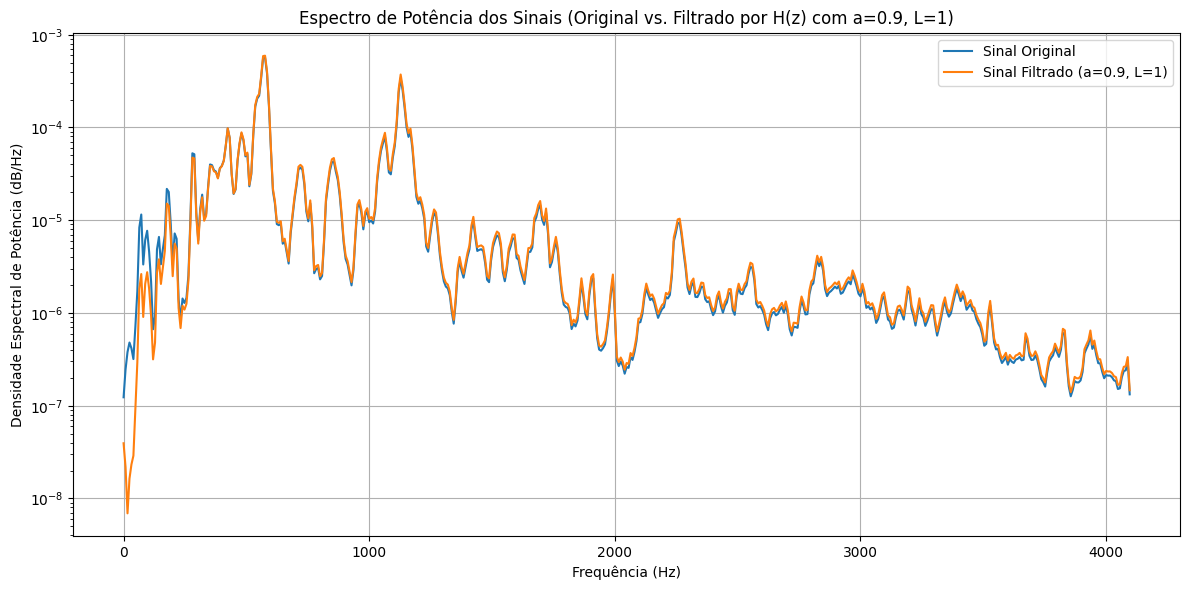


--- Analisando o efeito de H(z) no áudio com a = 0.9, L = 4 ---


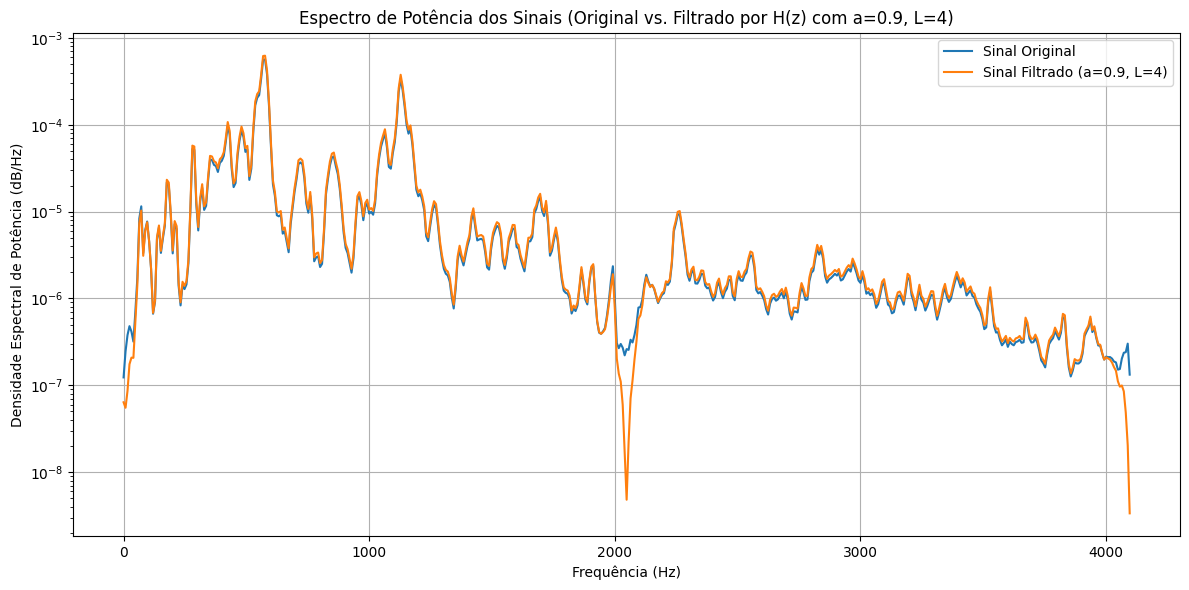


--- Analisando o efeito de H(z) no áudio com a = 0.9, L = 10 ---


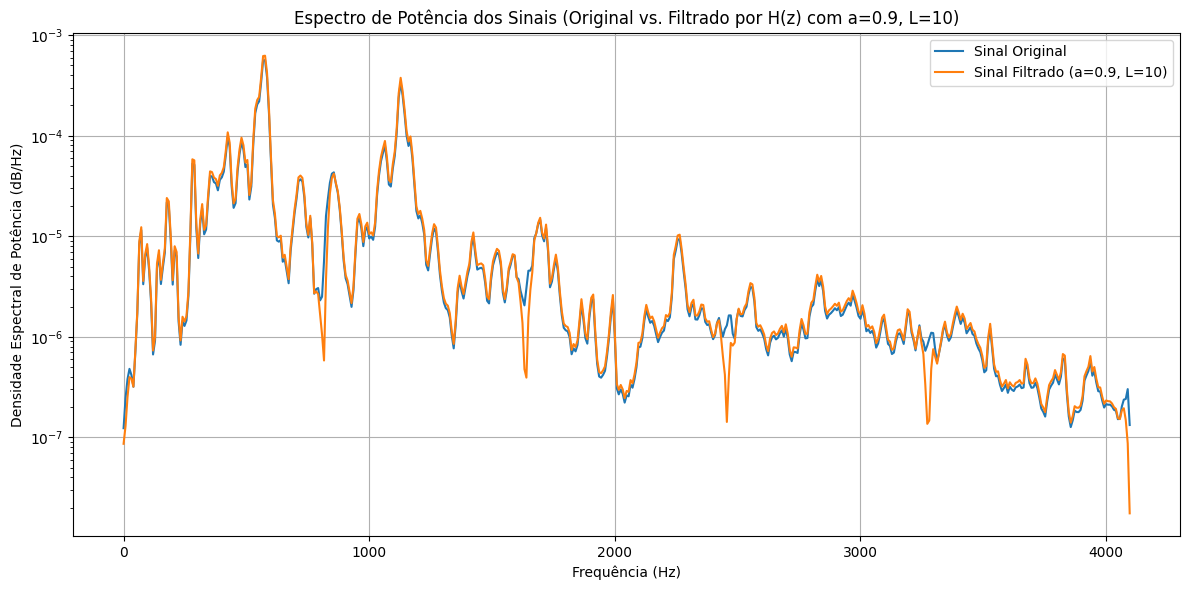

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy import signal

# Certifique-se de que o áudio foi carregado (pode ser necessário rodar a célula da parte 2 novamente)
# Se o kernel foi reiniciado, as variáveis 'sampling_rate' e 'audio_data' podem não estar disponíveis.
try:
    # Tenta usar as variáveis existentes
    _ = sampling_rate
    _ = audio_data
except NameError:
    # Se não existirem, carrega o arquivo de áudio novamente
    sampling_rate, audio_data = wavfile.read('/content/handel.wav')
    if audio_data.ndim > 1:
        audio_data = audio_data[:, 0]
    audio_data = audio_data / np.max(np.abs(audio_data))

# 5. Repita a Questão 2 com os sistemas da Questão 4.
# Para cada combinação de a e L, aplique H(z) ao áudio e plote o espectro.

valores_a = [0.7, 0.9]
valores_L = [1, 4, 10]

# Calcule o espectro do sinal original uma vez
freq_original, Pxx_den_original = signal.welch(audio_data, sampling_rate, nperseg=1024)

for a_val in valores_a:
    for L_val in valores_L:
        print(f"\n--- Analisando o efeito de H(z) no áudio com a = {a_val}, L = {L_val} ---")

        # Coeficientes do numerador (b) e denominador (a) para H(z) = (1 - z^-L) / (1 - a z^-L)
        b_coeffs = np.zeros(L_val + 1)
        b_coeffs[0] = 1.0
        b_coeffs[L_val] = -1.0

        a_coeffs = np.zeros(L_val + 1)
        a_coeffs[0] = 1.0
        a_coeffs[L_val] = -a_val

        # Aplique o filtro H(z) ao sinal de áudio
        filtered_audio_q4 = signal.lfilter(b_coeffs, a_coeffs, audio_data)

        # Calcule o espectro do sinal filtrado
        freq_filtered_q4, Pxx_den_filtered_q4 = signal.welch(filtered_audio_q4, sampling_rate, nperseg=1024)

        # Plotagem dos espectros
        plt.figure(figsize=(12, 6))
        plt.semilogy(freq_original, Pxx_den_original, label='Sinal Original')
        plt.semilogy(freq_filtered_q4, Pxx_den_filtered_q4, label=f'Sinal Filtrado (a={a_val}, L={L_val})')
        plt.title(f'Espectro de Potência dos Sinais (Original vs. Filtrado por H(z) com a={a_val}, L={L_val})')
        plt.xlabel('Frequência (Hz)')
        plt.ylabel('Densidade Espectral de Potência (dB/Hz)')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


### Comentário dos Resultados (Parte 5):

Para cada uma das seis combinações de `a` e `L`, observamos como o filtro `H(z) = (1 - z^-L) / (1 - a z^-L)` modifica o espectro de potência do sinal de áudio `handel.wav`.

*   **Filtros com L=1 (Passa-altas):**
    *   `a=0.7, L=1`: O filtro atua como um passa-altas, atenuando as baixas frequências do sinal de áudio e realçando as altas frequências. Isso se manifesta no espectro filtrado com uma redução na energia em baixas frequências e um aumento relativo em altas frequências, conforme a resposta em magnitude vista na Parte 4.
    *   `a=0.9, L=1`: Similar ao `a=0.7, L=1`, mas com uma característica passa-altas mais acentuada. A atenuação nas baixas frequências é um pouco menos profunda, e o realce nas altas frequências pode ser mais pronunciado devido ao polo estar mais próximo do círculo unitário, resultando em um pico de ressonância mais alto nas frequências mais elevadas.

*   **Filtros com L=4 e L=10 (Filtros Pente):**
    *   Para `L=4` e `L=10`, os filtros exibem o comportamento de um **filtro pente (comb filter)**. Eles criam múltiplos entalhes (atenuação) e picos (realce) periódicos no espectro. As frequências de entalhe e pico são determinadas por `L`.
    *   **Comentários Gerais sobre Filtros Pente:**
        *   **Entalhes (Valleys):** As frequências onde o filtro H(z) tem magnitude baixa ou nula correspondem às frequências que são significativamente atenuadas no sinal de áudio filtrado. No espectro, isso aparece como 'buracos' ou vales na densidade de potência.
        *   **Picos (Peaks):** As frequências onde o filtro H(z) tem magnitude alta correspondem às frequências que são realçadas no sinal de áudio filtrado. No espectro, isso se traduz em aumentos na densidade de potência.
        *   **Influência de 'a':** Quanto mais próximo `a` está de 1 (e.g., `a=0.9` vs. `a=0.7`), mais nítidos e profundos se tornam os entalhes e mais altos e estreitos os picos. Isso significa que o filtro se torna mais seletivo, com atenuações e realces mais fortes em bandas de frequência específicas. Isso é claramente visível ao comparar os espectros filtrados para o mesmo `L` mas com diferentes `a`.
        *   **Influência de 'L':** Um `L` maior (e.g., `L=10` vs. `L=4`) resulta em mais entalhes e picos no espectro, distribuídos mais densamente ao longo da faixa de frequência. O "padrão de pente" se repete mais vezes, indicando que o filtro afeta um maior número de frequências de forma periódica.

Em resumo, a aplicação desses filtros ao sinal de áudio demonstra visualmente como suas características de resposta em frequência (determinadas por `a` e `L`) se traduzem em modificações no conteúdo espectral do áudio, atenuando ou realçando bandas de frequência específicas.

### Comentário dos Resultados (Parte 5):

Para cada uma das seis combinações de `a` e `L`, observamos como o filtro `H(z) = (1 - z^-L) / (1 - a z^-L)` modifica o espectro de potência do sinal de áudio `handel.wav`.

*   **Filtros com L=1 (Passa-altas):**
    *   `a=0.7, L=1`: O filtro atua como um passa-altas, atenuando as baixas frequências do sinal de áudio e realçando as altas frequências. Isso se manifesta no espectro filtrado com uma redução na energia em baixas frequências e um aumento relativo em altas frequências, conforme a resposta em magnitude vista na Parte 4.
    *   `a=0.9, L=1`: Similar ao `a=0.7, L=1`, mas com uma característica passa-altas mais acentuada. A atenuação nas baixas frequências é um pouco menos profunda, e o realce nas altas frequências pode ser mais pronunciado devido ao polo estar mais próximo do círculo unitário, resultando em um pico de ressonância mais alto nas frequências mais elevadas.

*   **Filtros com L=4 e L=10 (Filtros Pente):**
    *   Para `L=4` e `L=10`, os filtros exibem o comportamento de um **filtro pente (comb filter)**. Eles criam múltiplos entalhes (atenuação) e picos (realce) periódicos no espectro. As frequências de entalhe e pico são determinadas por `L`.
    *   **Comentários Gerais sobre Filtros Pente:**
        *   **Entalhes (Valleys):** As frequências onde o filtro H(z) tem magnitude baixa ou nula correspondem às frequências que são significativamente atenuadas no sinal de áudio filtrado. No espectro, isso aparece como 'buracos' ou vales na densidade de potência.
        *   **Picos (Peaks):** As frequências onde o filtro H(z) tem magnitude alta correspondem às frequências que são realçadas no sinal de áudio filtrado. No espectro, isso se traduz em aumentos na densidade de potência.
        *   **Influência de 'a':** Quanto mais próximo `a` está de 1 (e.g., `a=0.9` vs. `a=0.7`), mais nítidos e profundos se tornam os entalhes e mais altos e estreitos os picos. Isso significa que o filtro se torna mais seletivo, com atenuações e realces mais fortes em bandas de frequência específicas. Isso é claramente visível ao comparar os espectros filtrados para o mesmo `L` mas com diferentes `a`.
        *   **Influência de 'L':** Um `L` maior (e.g., `L=10` vs. `L=4`) resulta em mais entalhes e picos no espectro, distribuídos mais densamente ao longo da faixa de frequência. O "padrão de pente" se repete mais vezes, indicando que o filtro afeta um maior número de frequências de forma periódica.

Em resumo, a aplicação desses filtros ao sinal de áudio demonstra visualmente como suas características de resposta em frequência (determinadas por `a` e `L`) se traduzem em modificações no conteúdo espectral do áudio, atenuando ou realçando bandas de frequência específicas.


--- Projetando e avaliando filtro inverso para a = 0.7, L = 1 ---


/usr/local/lib/python3.12/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: divide by zero encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /
/usr/local/lib/python3.12/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: invalid value encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /


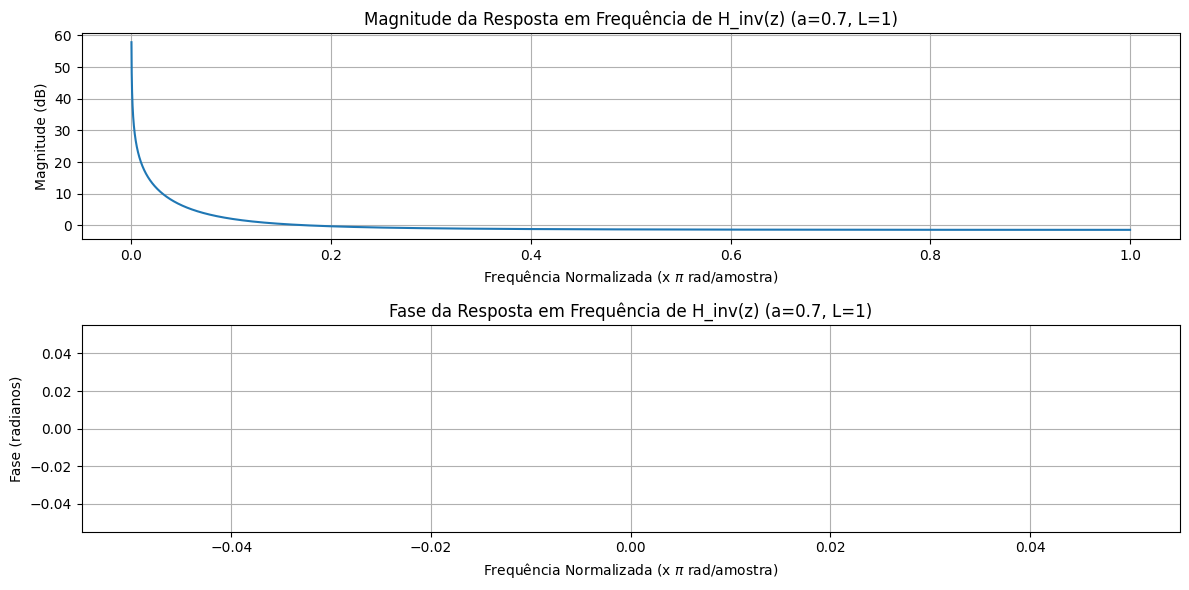

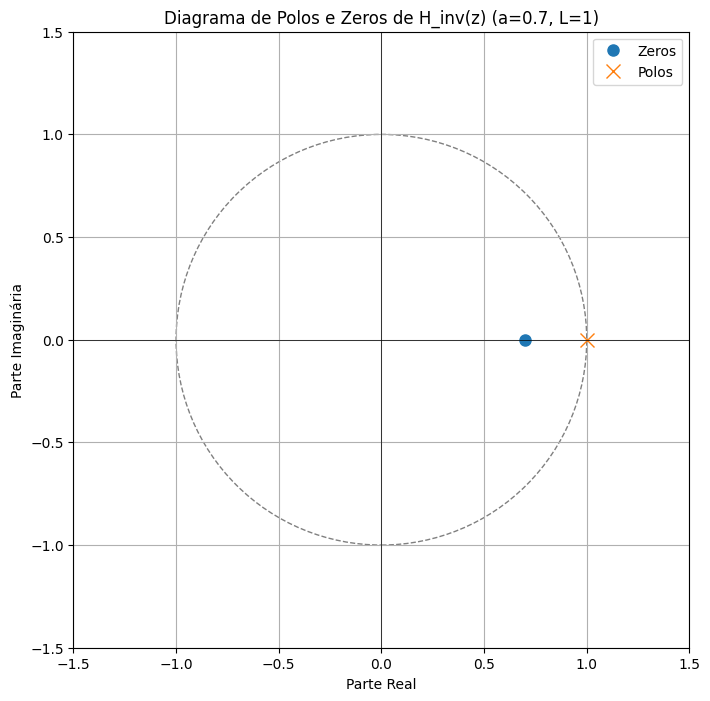

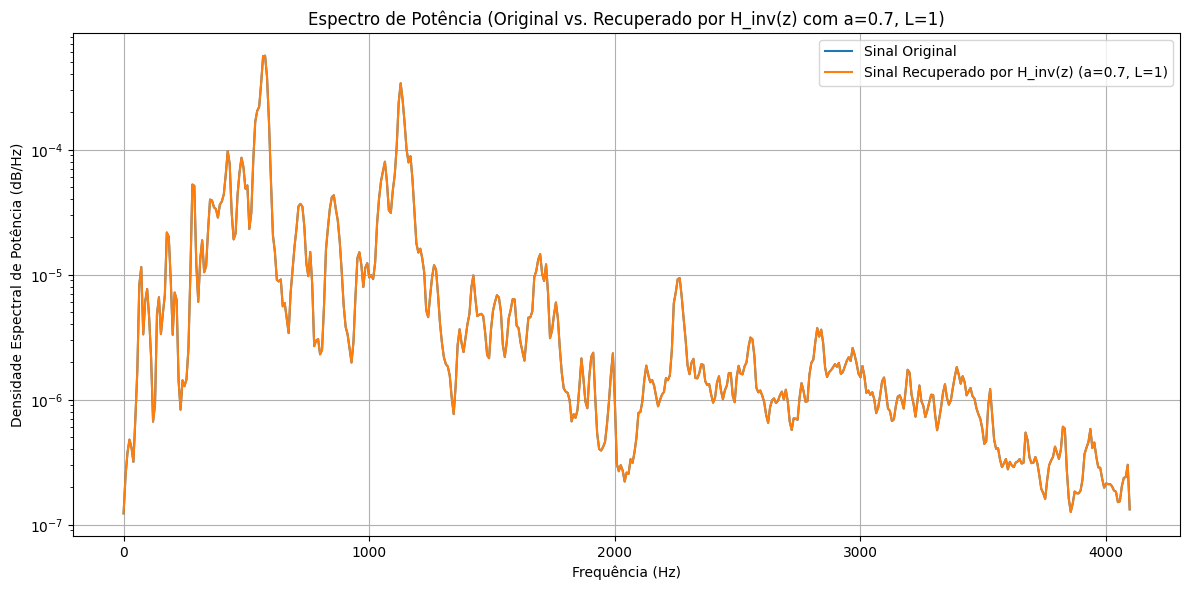

  Erro Quadrático Médio (MSE) entre o sinal original e o recuperado: 3.2571e-30
  Relação Sinal-Ruído (SNR) entre o sinal original e o recuperado: 282.66 dB

--- Projetando e avaliando filtro inverso para a = 0.7, L = 4 ---


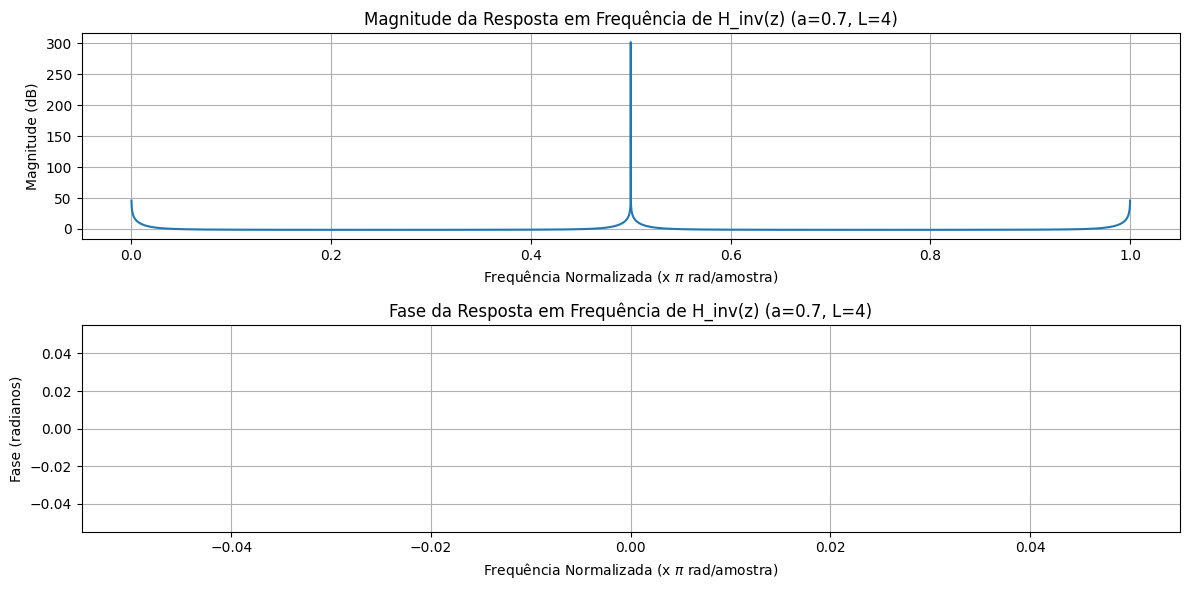

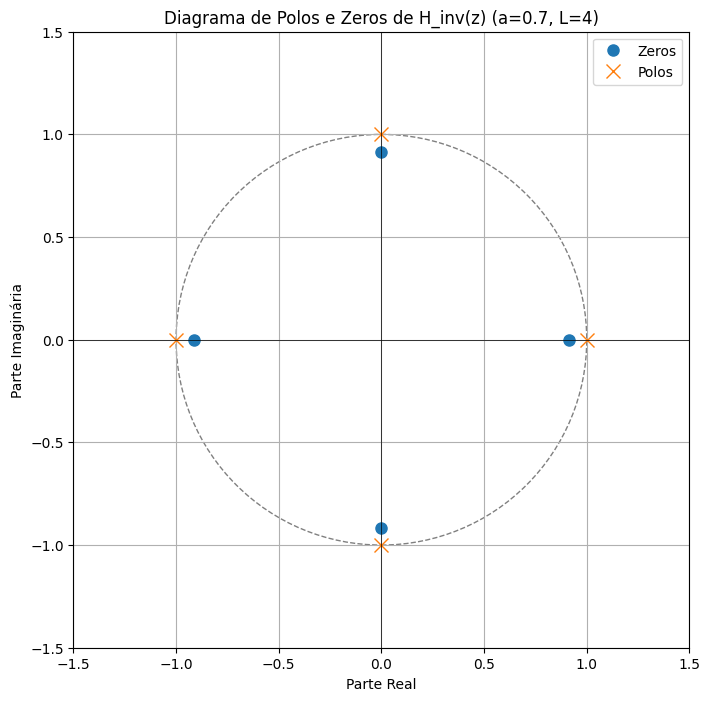

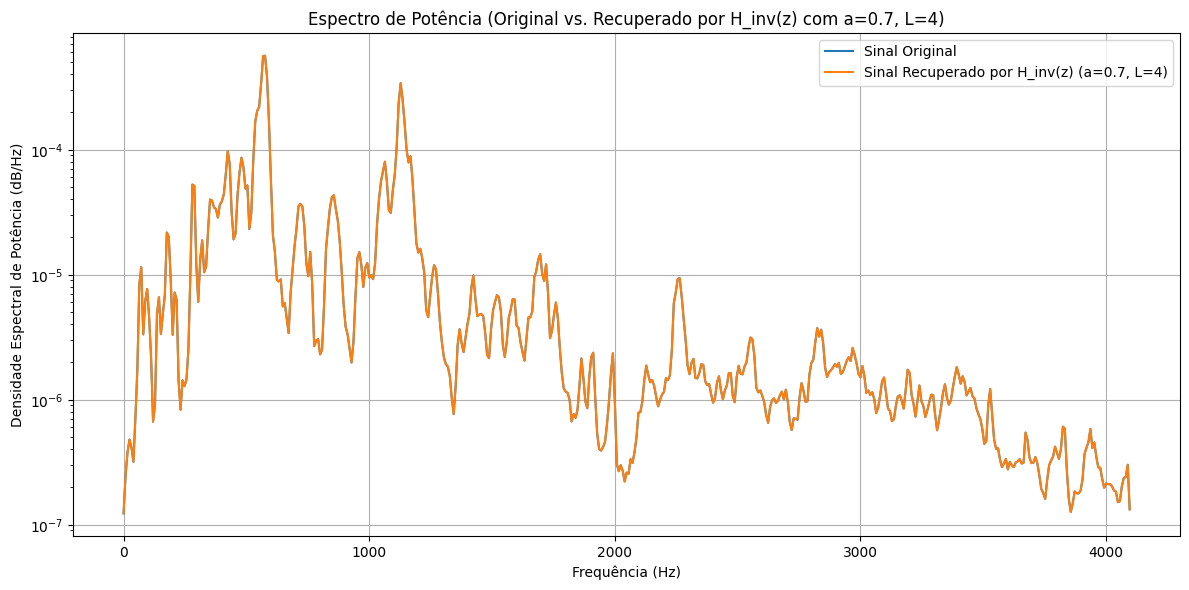

  Erro Quadrático Médio (MSE) entre o sinal original e o recuperado: 1.9372e-30
  Relação Sinal-Ruído (SNR) entre o sinal original e o recuperado: 284.92 dB

--- Projetando e avaliando filtro inverso para a = 0.7, L = 10 ---


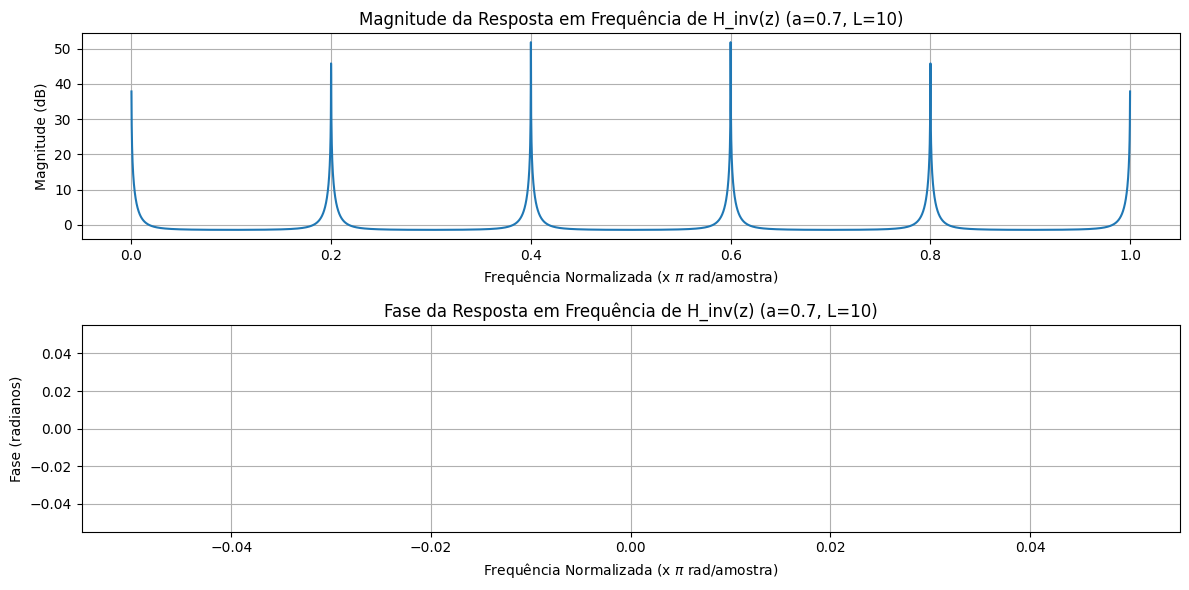

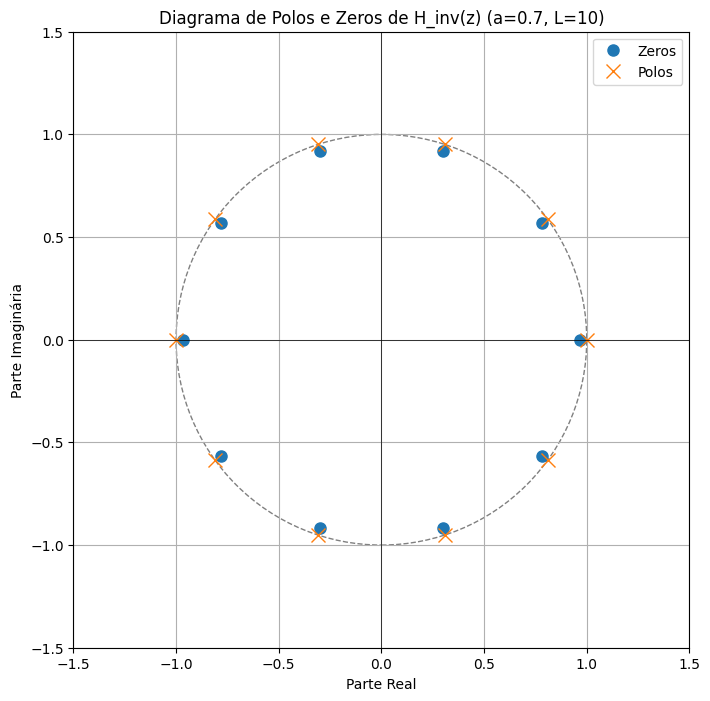

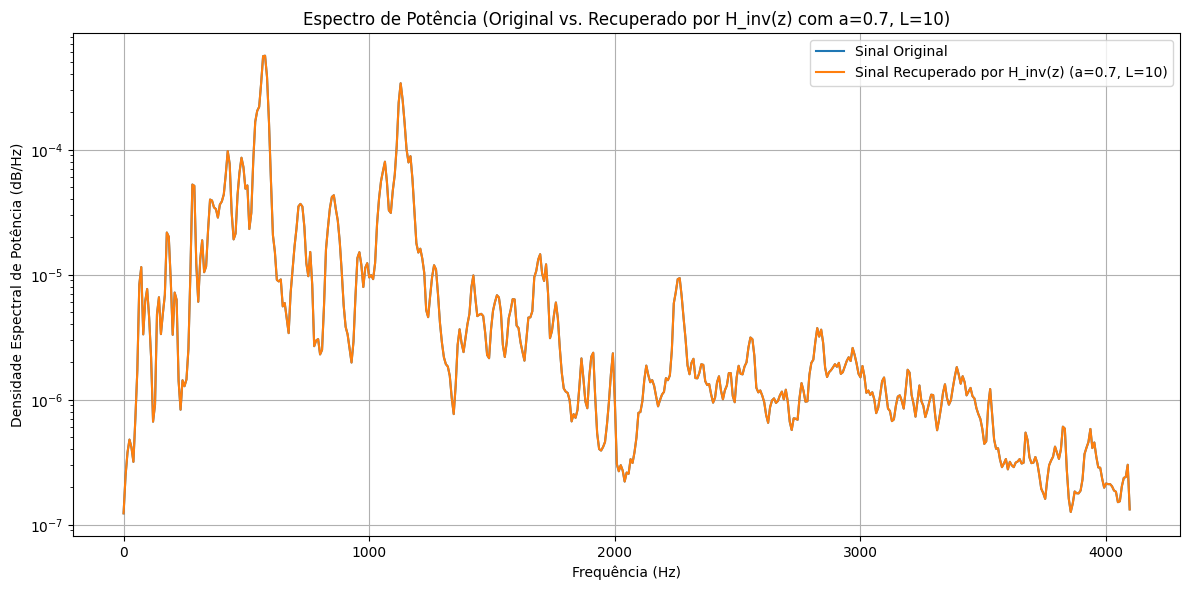

  Erro Quadrático Médio (MSE) entre o sinal original e o recuperado: 1.3475e-30
  Relação Sinal-Ruído (SNR) entre o sinal original e o recuperado: 286.50 dB

--- Projetando e avaliando filtro inverso para a = 0.9, L = 1 ---


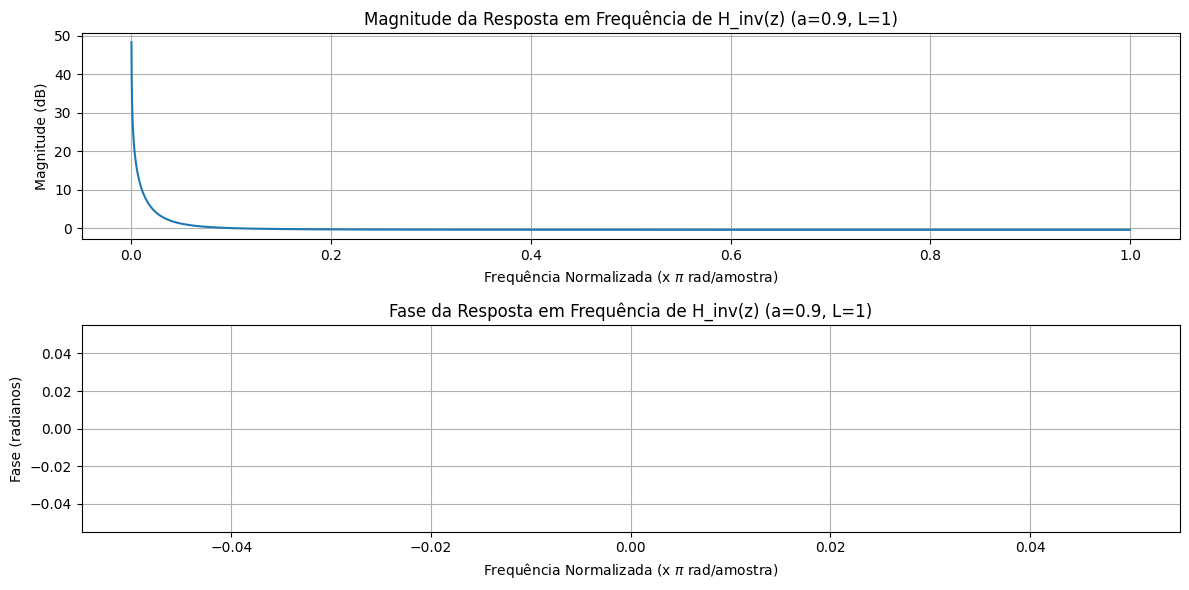

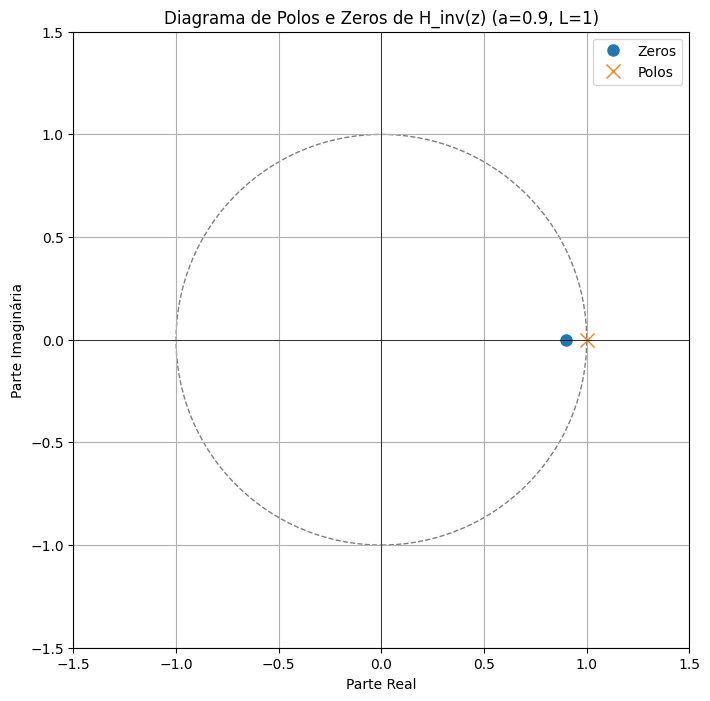

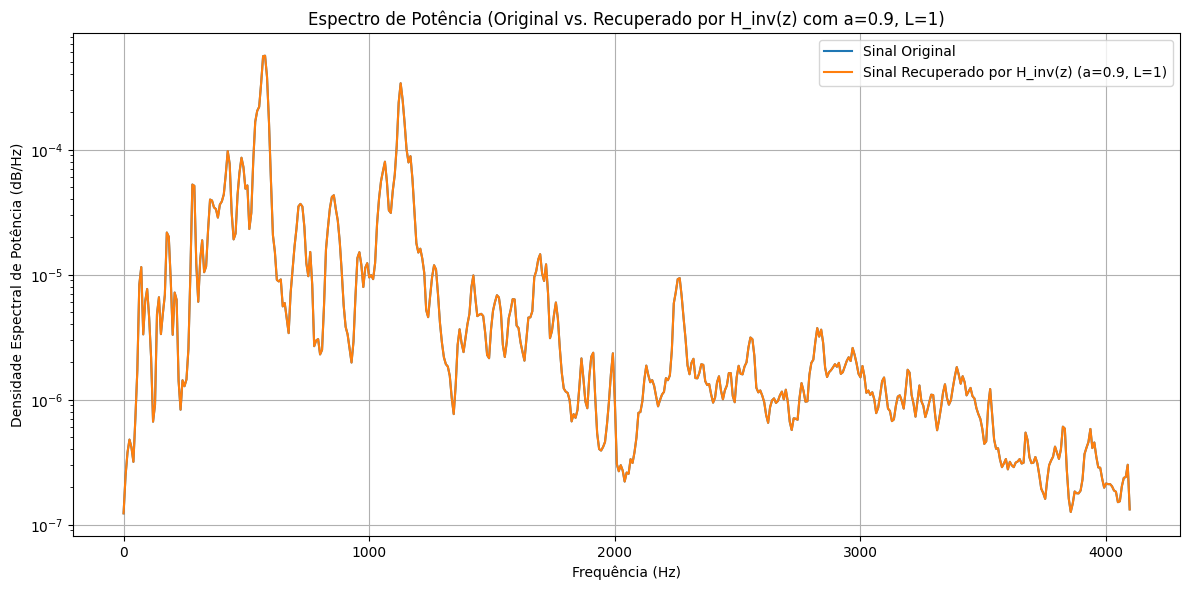

  Erro Quadrático Médio (MSE) entre o sinal original e o recuperado: 1.0693e-30
  Relação Sinal-Ruído (SNR) entre o sinal original e o recuperado: 287.50 dB

--- Projetando e avaliando filtro inverso para a = 0.9, L = 4 ---


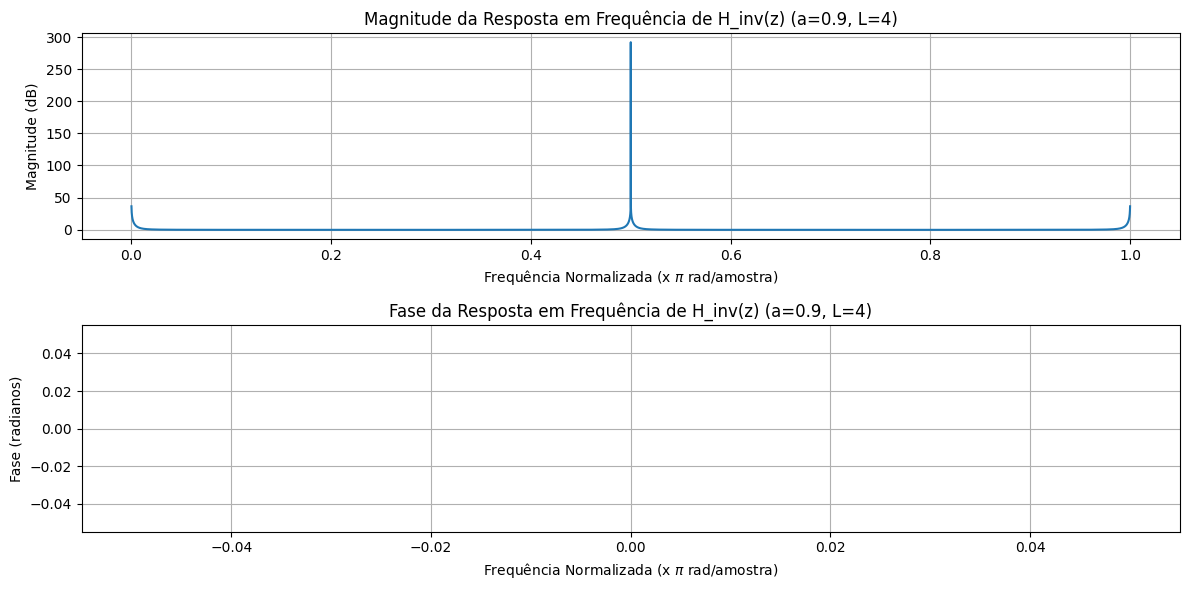

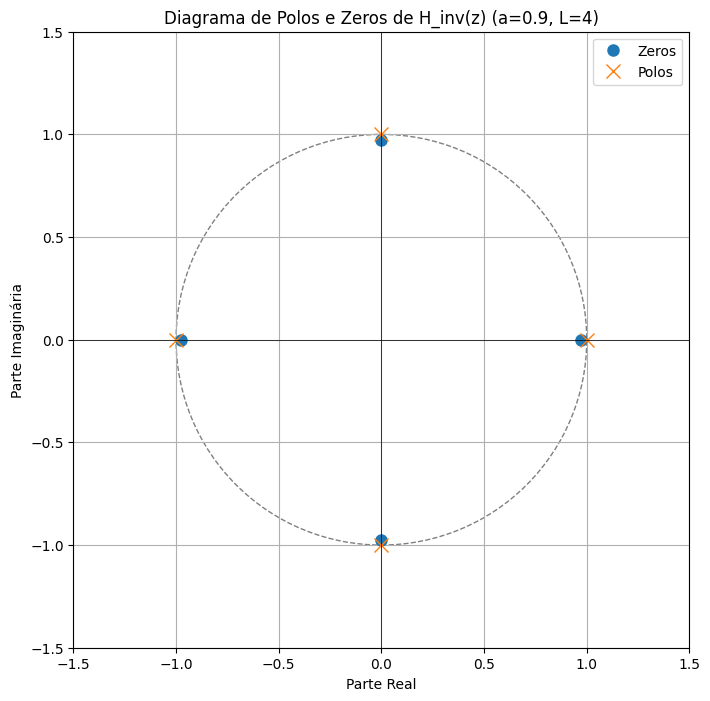

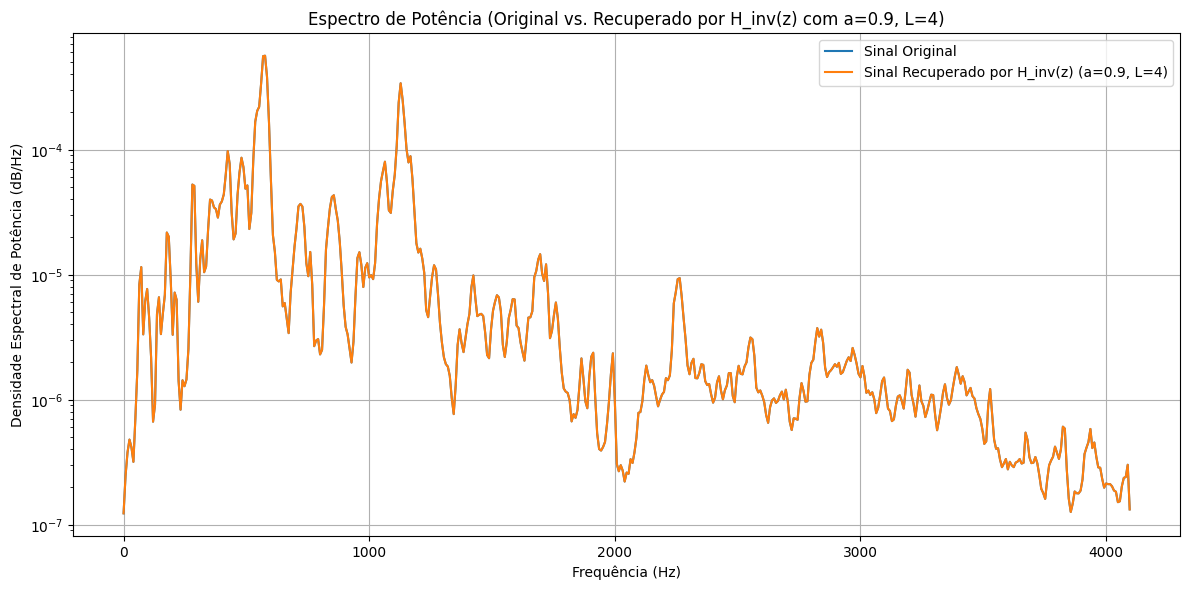

  Erro Quadrático Médio (MSE) entre o sinal original e o recuperado: 1.2501e-30
  Relação Sinal-Ruído (SNR) entre o sinal original e o recuperado: 286.82 dB

--- Projetando e avaliando filtro inverso para a = 0.9, L = 10 ---


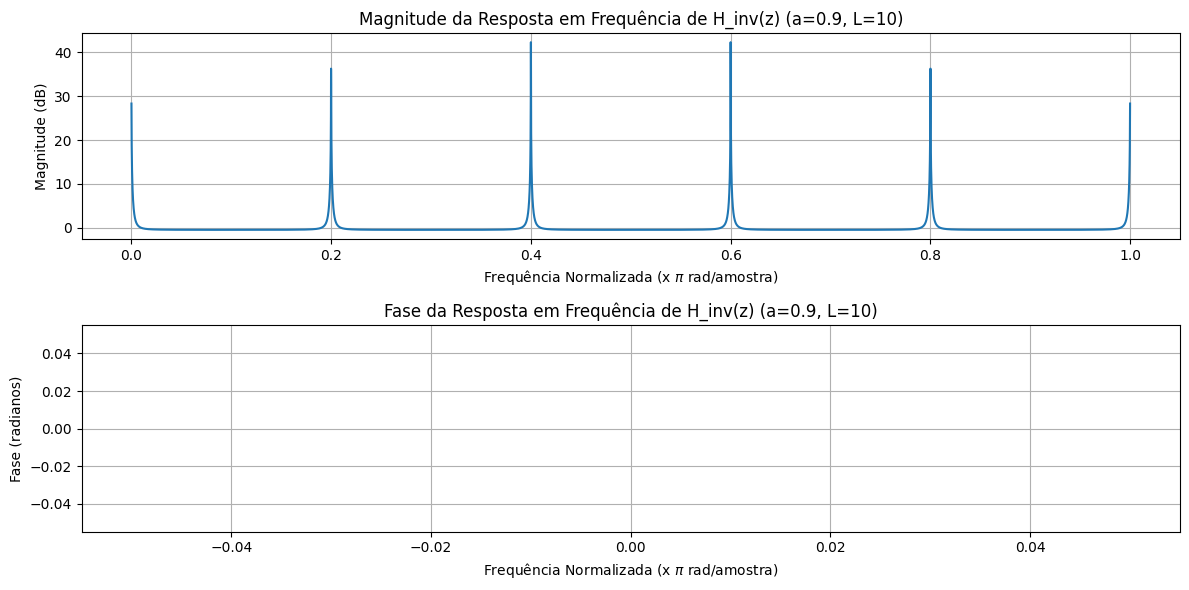

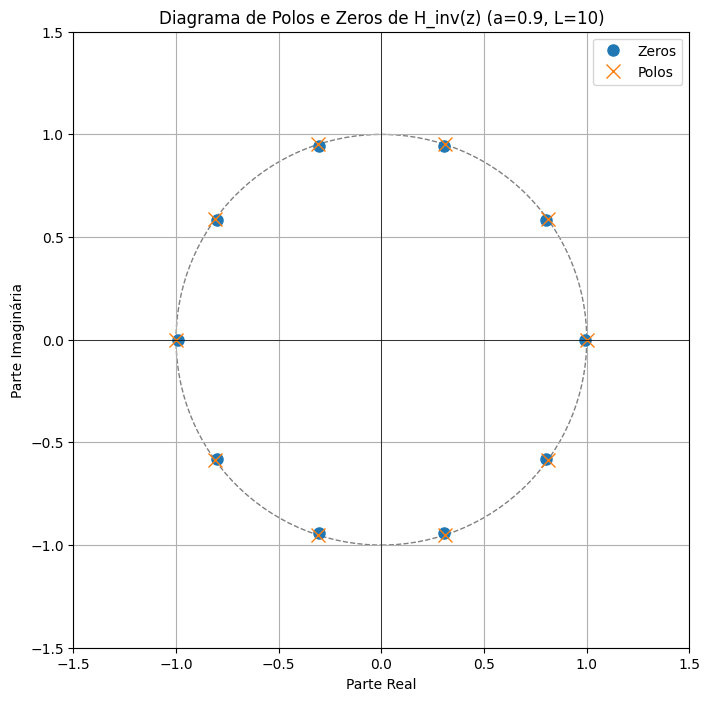

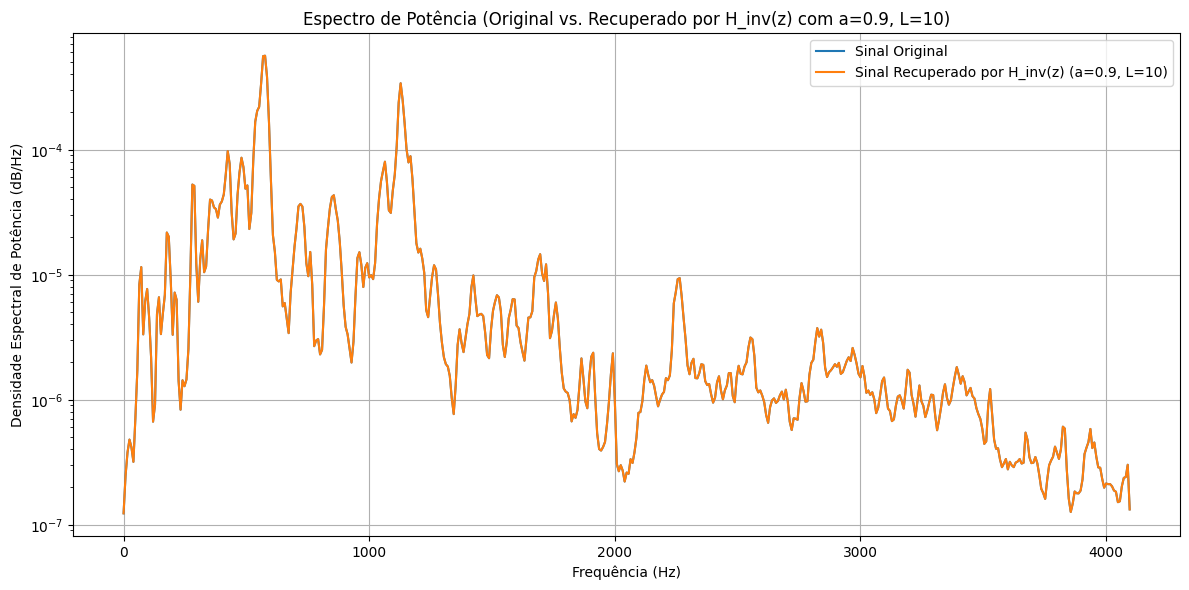

  Erro Quadrático Médio (MSE) entre o sinal original e o recuperado: 1.0949e-30
  Relação Sinal-Ruído (SNR) entre o sinal original e o recuperado: 287.40 dB


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile

# Certifique-se de que o áudio foi carregado (pode ser necessário rodar a célula da parte 2 novamente)
# Se o kernel foi reiniciado, as variáveis 'sampling_rate' e 'audio_data' podem não estar disponíveis.
try:
    _ = sampling_rate
    _ = audio_data
    _ = freq_original
    _ = Pxx_den_original
except NameError:
    sampling_rate, audio_data = wavfile.read('/content/handel.wav')
    if audio_data.ndim > 1:
        audio_data = audio_data[:, 0]
    audio_data = audio_data / np.max(np.abs(audio_data))
    freq_original, Pxx_den_original = signal.welch(audio_data, sampling_rate, nperseg=1024)

# 6. Para os sistemas da Questão 4, projete filtros para recuperar o sinal de áudio original, mostre
# sua resposta em frequência, seu diagrama de polos e zeros. Avalie quão próximo o sinal recuperado
# é do sinal original e comente os resultados obtidos.

valores_a = [0.7, 0.9]
valores_L = [1, 4, 10]

for a_val in valores_a:
    for L_val in valores_L:
        print(f"\n--- Projetando e avaliando filtro inverso para a = {a_val}, L = {L_val} ---")

        # Filtro original H(z) = b_coeffs_q4 / a_coeffs_q4
        b_coeffs_q4 = np.zeros(L_val + 1)
        b_coeffs_q4[0] = 1.0
        b_coeffs_q4[L_val] = -1.0

        a_coeffs_q4 = np.zeros(L_val + 1)
        a_coeffs_q4[0] = 1.0
        a_coeffs_q4[L_val] = -a_val

        # Filtro inverso H_inv(z) = a_coeffs_q4 / b_coeffs_q4
        b_inv_q6 = a_coeffs_q4  # Numerador do inverso é o denominador do original
        a_inv_q6 = b_coeffs_q4  # Denominador do inverso é o numerador do original

        # Calcule a resposta em frequência do filtro inverso
        ws_inv_q6, h_inv_q6 = signal.freqz(b_inv_q6, a_inv_q6, worN=8192)

        # Plotagem da Magnitude da Resposta em Frequência de H_inv(z)
        plt.figure(figsize=(12, 6))
        plt.subplot(2, 1, 1)
        plt.plot(ws_inv_q6 / np.pi, 20 * np.log10(abs(h_inv_q6)))
        plt.title(f'Magnitude da Resposta em Frequência de H_inv(z) (a={a_val}, L={L_val})')
        plt.xlabel(r'Frequência Normalizada (x $\pi$ rad/amostra)')
        plt.ylabel('Magnitude (dB)')
        plt.grid()

        # Plotagem da Fase da Resposta em Frequência de H_inv(z)
        plt.subplot(2, 1, 2)
        plt.plot(ws_inv_q6 / np.pi, np.unwrap(np.angle(h_inv_q6)))
        plt.title(f'Fase da Resposta em Frequência de H_inv(z) (a={a_val}, L={L_val})')
        plt.xlabel(r'Frequência Normalizada (x $\pi$ rad/amostra)')
        plt.ylabel('Fase (radianos)')
        plt.grid()
        plt.tight_layout()
        plt.show()

        # Calcule os polos e zeros de H_inv(z)
        z_inv_q6, p_inv_q6, k_inv_q6 = signal.tf2zpk(b_inv_q6, a_inv_q6)

        # Plotagem do Diagrama de Polos e Zeros de H_inv(z)
        plt.figure(figsize=(8, 8))
        plt.plot(np.real(z_inv_q6), np.imag(z_inv_q6), 'o', markersize=8, label='Zeros')
        plt.plot(np.real(p_inv_q6), np.imag(p_inv_q6), 'x', markersize=10, label='Polos')

        # Desenhe o círculo unitário
        circle = plt.Circle((0, 0), 1, color='gray', linestyle='--', fill=False)
        plt.gca().add_artist(circle)

        plt.title(f'Diagrama de Polos e Zeros de H_inv(z) (a={a_val}, L={L_val})')
        plt.xlabel('Parte Real')
        plt.ylabel('Parte Imaginária')
        plt.grid()
        plt.axvline(0, color='black', linewidth=0.5)
        plt.axhline(0, color='black', linewidth=0.5)
        plt.xlim([-1.5, 1.5])
        plt.ylim([-1.5, 1.5])
        plt.legend()
        plt.gca().set_aspect('equal', adjustable='box')
        plt.show()

        # Aplicar o filtro original H(z) para obter o sinal 'filtrado' para este caso
        # (isso é feito em Questão 5, mas repetimos aqui para garantir que filtered_audio_q4 existe)
        filtered_audio_q4_current = signal.lfilter(b_coeffs_q4, a_coeffs_q4, audio_data)

        # Aplique o filtro inverso para recuperar o sinal
        recovered_audio_q6 = signal.lfilter(b_inv_q6, a_inv_q6, filtered_audio_q4_current)

        # Garanta que os sinais têm o mesmo comprimento para comparação
        min_len = min(len(audio_data), len(recovered_audio_q6))
        original_trimmed_q6 = audio_data[:min_len]
        recovered_trimmed_q6 = recovered_audio_q6[:min_len]

        # Calcule o espectro do sinal recuperado
        freq_recovered_q6, Pxx_den_recovered_q6 = signal.welch(recovered_trimmed_q6, sampling_rate, nperseg=1024)

        # Plotagem dos espectros para comparação (original vs recuperado)
        plt.figure(figsize=(12, 6))
        plt.semilogy(freq_original, Pxx_den_original, label='Sinal Original')
        plt.semilogy(freq_recovered_q6, Pxx_den_recovered_q6, label=f'Sinal Recuperado por H_inv(z) (a={a_val}, L={L_val})')
        plt.title(f'Espectro de Potência (Original vs. Recuperado por H_inv(z) com a={a_val}, L={L_val})')
        plt.xlabel('Frequência (Hz)')
        plt.ylabel('Densidade Espectral de Potência (dB/Hz)')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

        # Avalie a proximidade usando o Erro Quadrático Médio (MSE)
        mse_q6 = np.mean((original_trimmed_q6 - recovered_trimmed_q6)**2)
        print(f"  Erro Quadrático Médio (MSE) entre o sinal original e o recuperado: {mse_q6:.4e}")

        # Opcional: Avaliar usando Relação Sinal Ruído (SNR)
        signal_power_q6 = np.mean(original_trimmed_q6**2)
        noise_power_q6 = np.mean((original_trimmed_q6 - recovered_trimmed_q6)**2)

        if noise_power_q6 > 0:
            snr_db_q6 = 10 * np.log10(signal_power_q6 / noise_power_q6)
            print(f"  Relação Sinal-Ruído (SNR) entre o sinal original e o recuperado: {snr_db_q6:.2f} dB")
        else:
            print("  Ruído (diferença) é zero, SNR é infinito (recuperação perfeita).")


## Questão 7: Aproximações FIR dos Filtros Inversos e Análise da Qualidade de Recuperação


--- 7.1. Aproximação FIR para o filtro inverso da Questão 3 ---


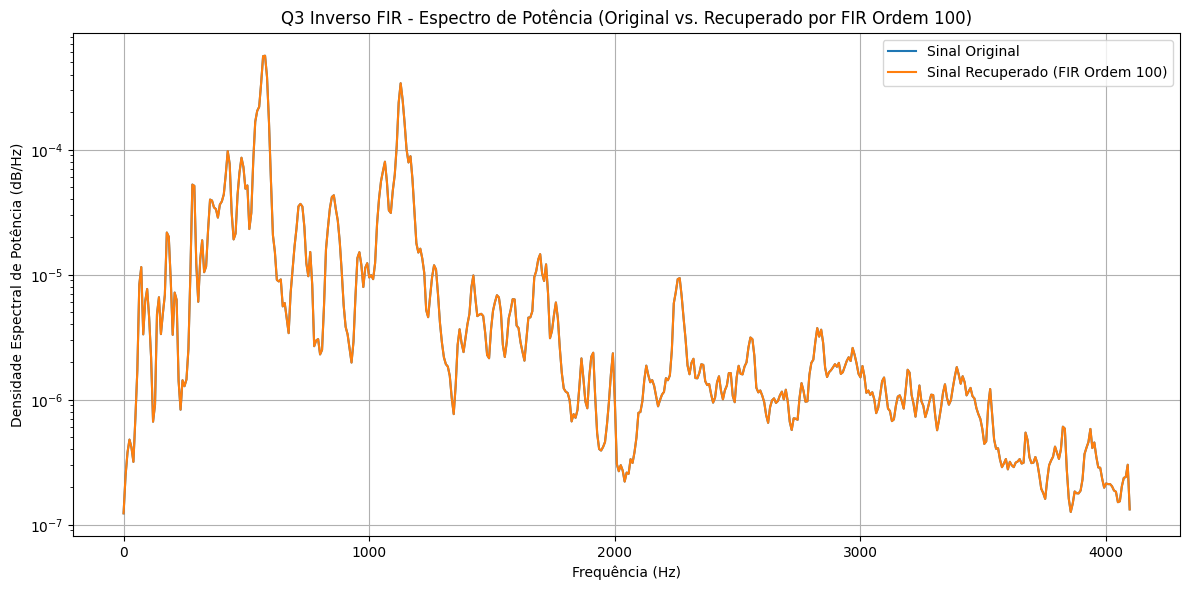

  Q3 Inverso FIR - Erro Quadrático Médio (MSE) para FIR Ordem 100: 9.4849e-09
  Q3 Inverso FIR - Relação Sinal-Ruído (SNR) para FIR Ordem 100: 68.02 dB


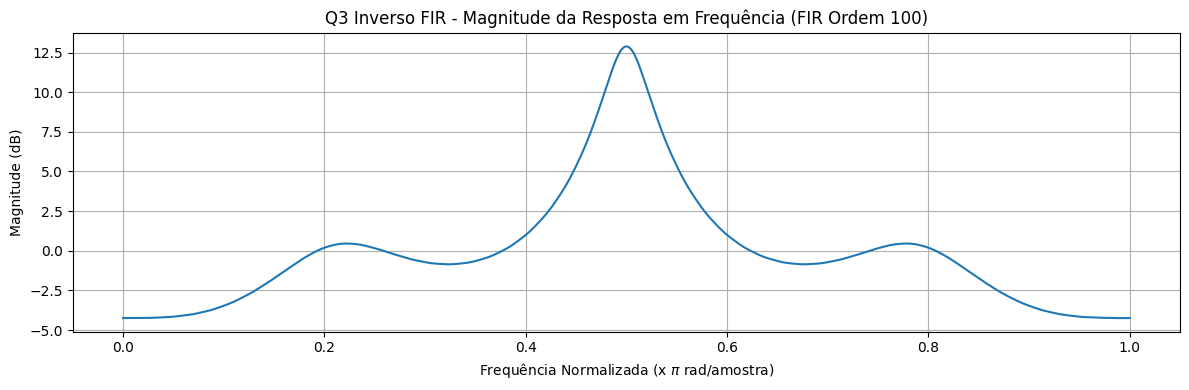

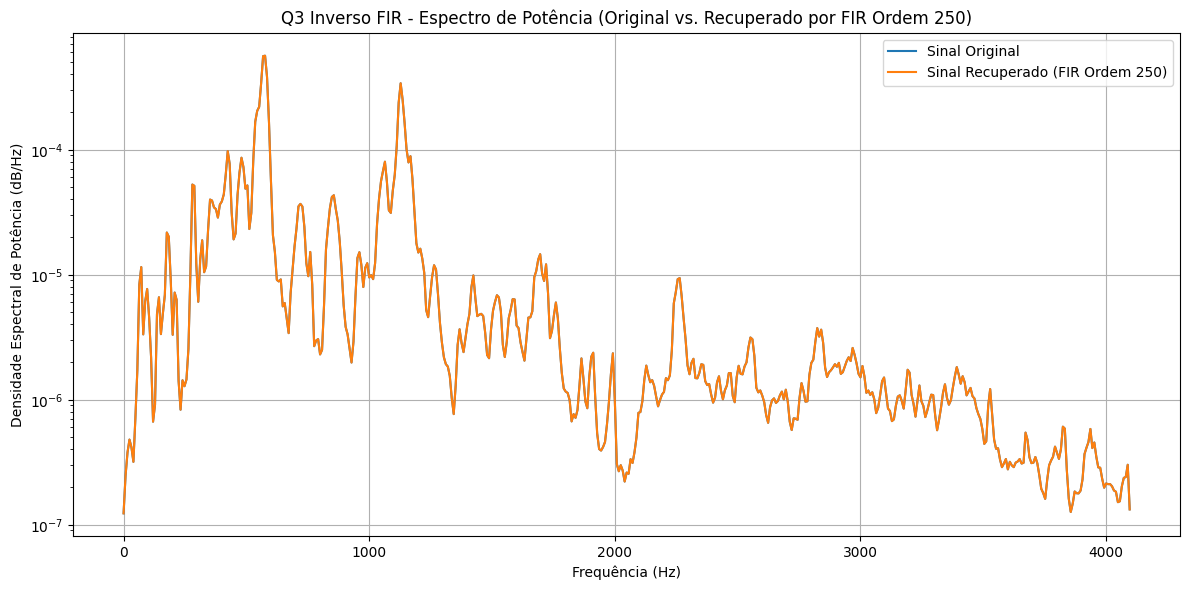

  Q3 Inverso FIR - Erro Quadrático Médio (MSE) para FIR Ordem 250: 1.0586e-17
  Q3 Inverso FIR - Relação Sinal-Ruído (SNR) para FIR Ordem 250: 157.55 dB


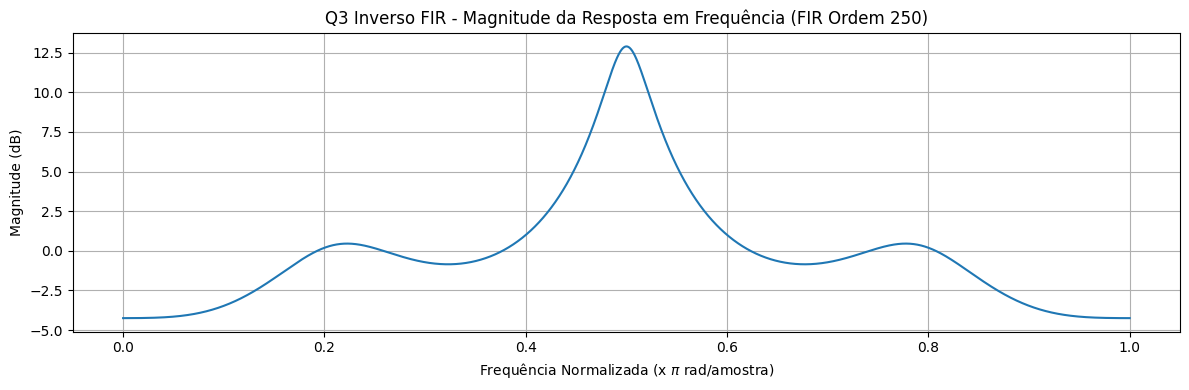


--- 7.2. Aproximação FIR para os filtros inversos da Questão 6 ---

--- Q6 Inverso FIR (a=0.7, L=1) ---


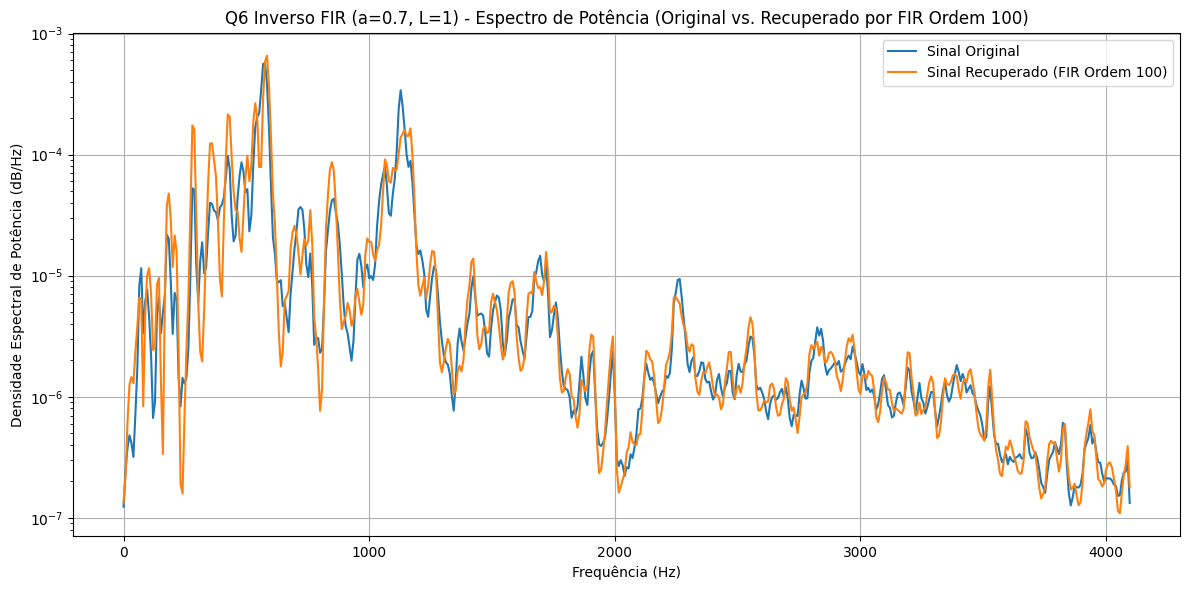

  Q6 Inverso FIR (a=0.7, L=1) - Erro Quadrático Médio (MSE) para FIR Ordem 100: 2.0071e-02
  Q6 Inverso FIR (a=0.7, L=1) - Relação Sinal-Ruído (SNR) para FIR Ordem 100: 4.77 dB


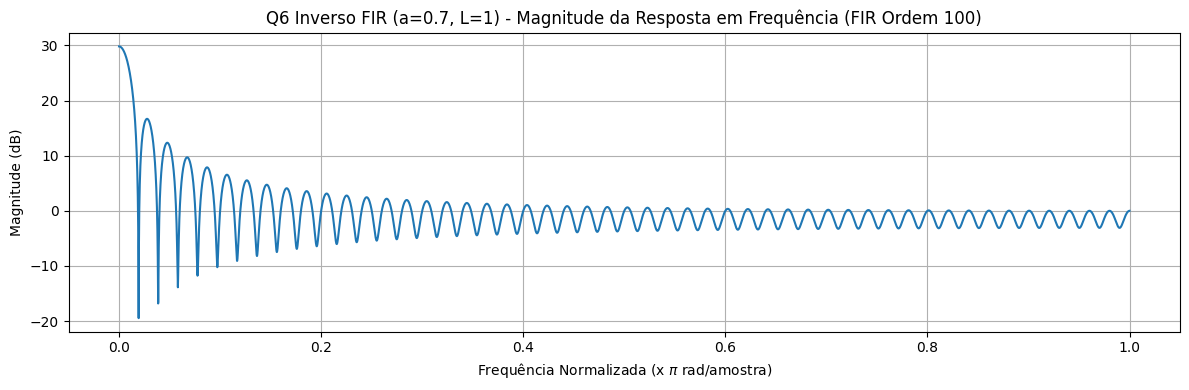

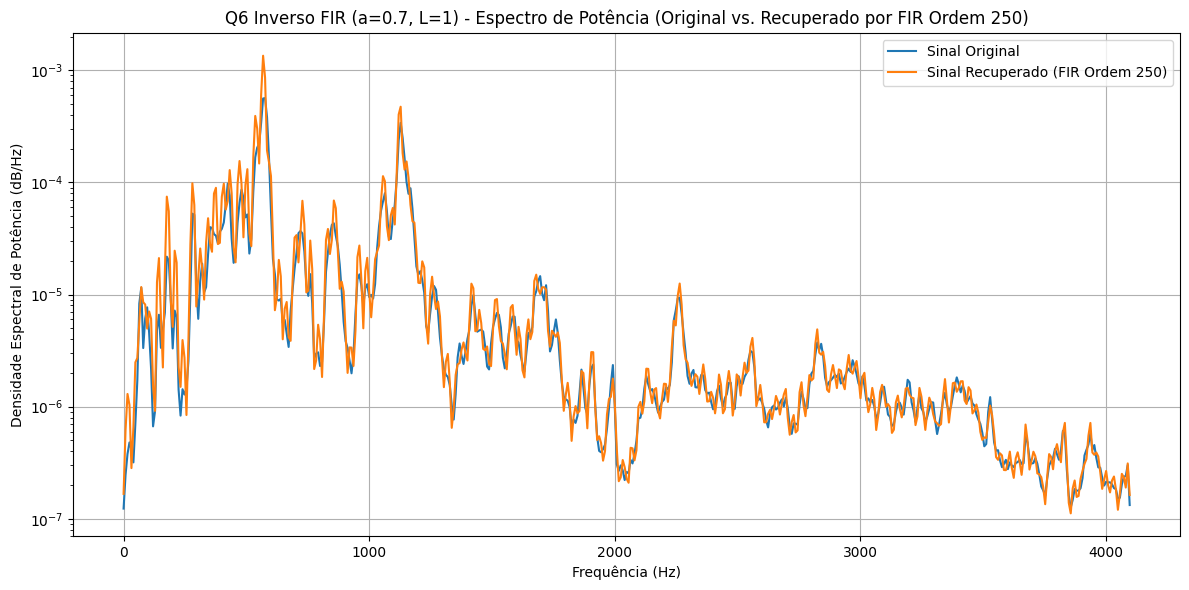

  Q6 Inverso FIR (a=0.7, L=1) - Erro Quadrático Médio (MSE) para FIR Ordem 250: 2.0057e-02
  Q6 Inverso FIR (a=0.7, L=1) - Relação Sinal-Ruído (SNR) para FIR Ordem 250: 4.77 dB


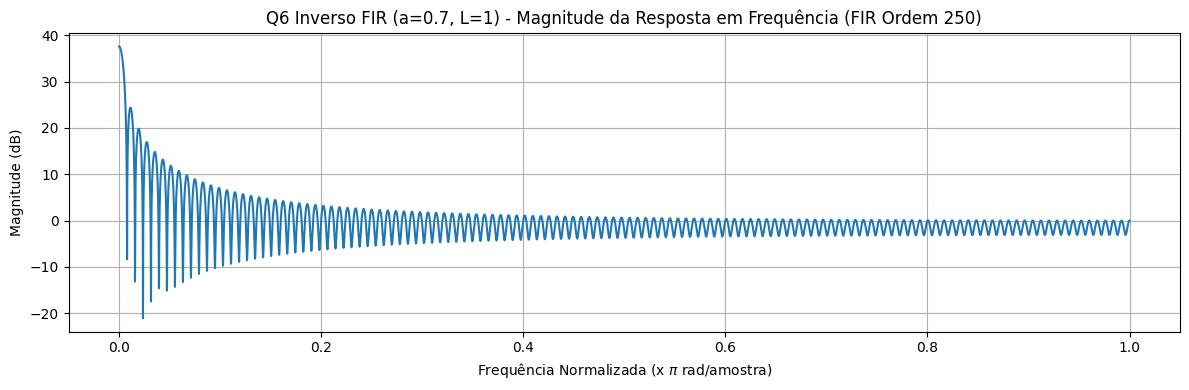


--- Q6 Inverso FIR (a=0.7, L=4) ---


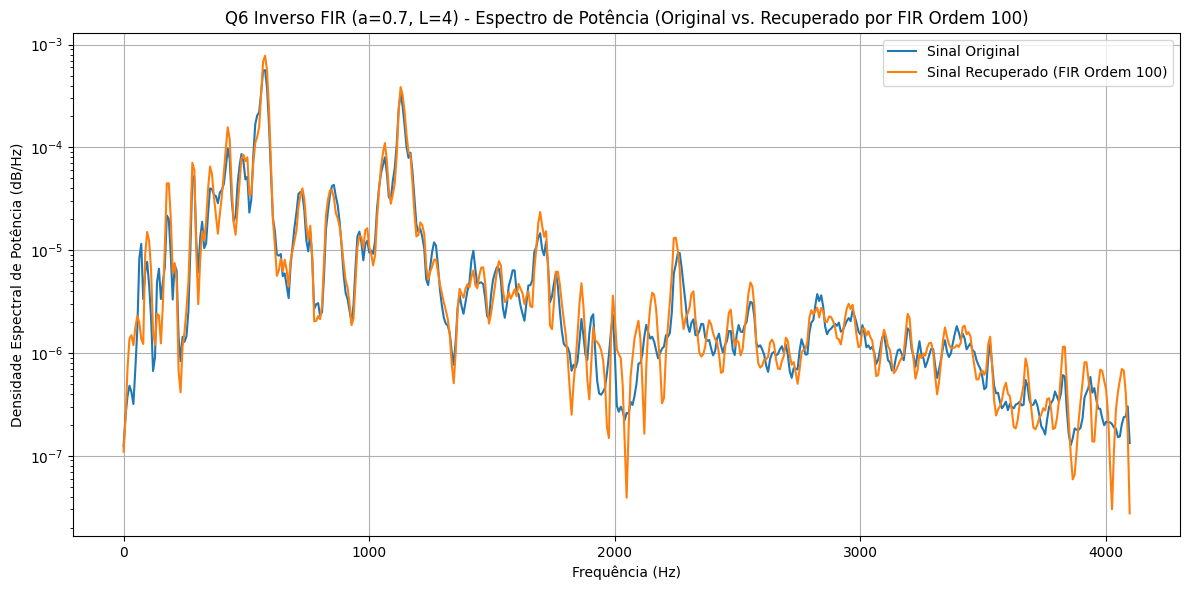

  Q6 Inverso FIR (a=0.7, L=4) - Erro Quadrático Médio (MSE) para FIR Ordem 100: 3.9236e-03
  Q6 Inverso FIR (a=0.7, L=4) - Relação Sinal-Ruído (SNR) para FIR Ordem 100: 11.86 dB


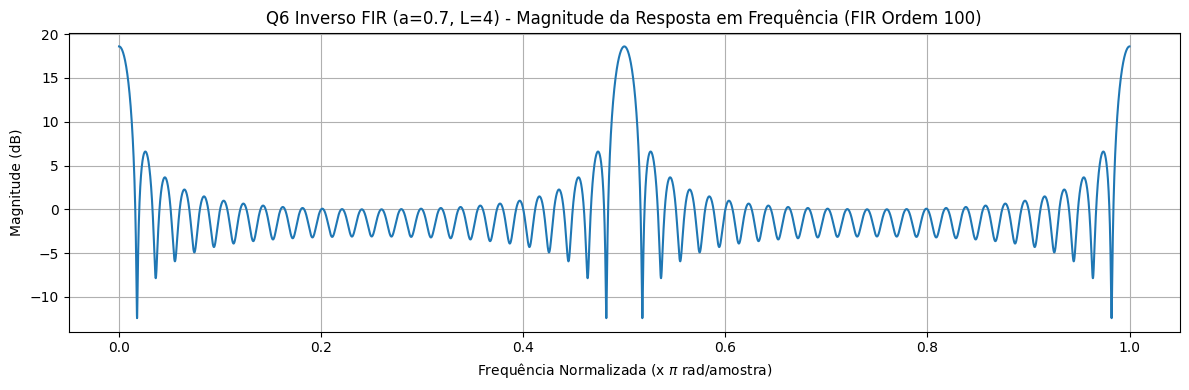

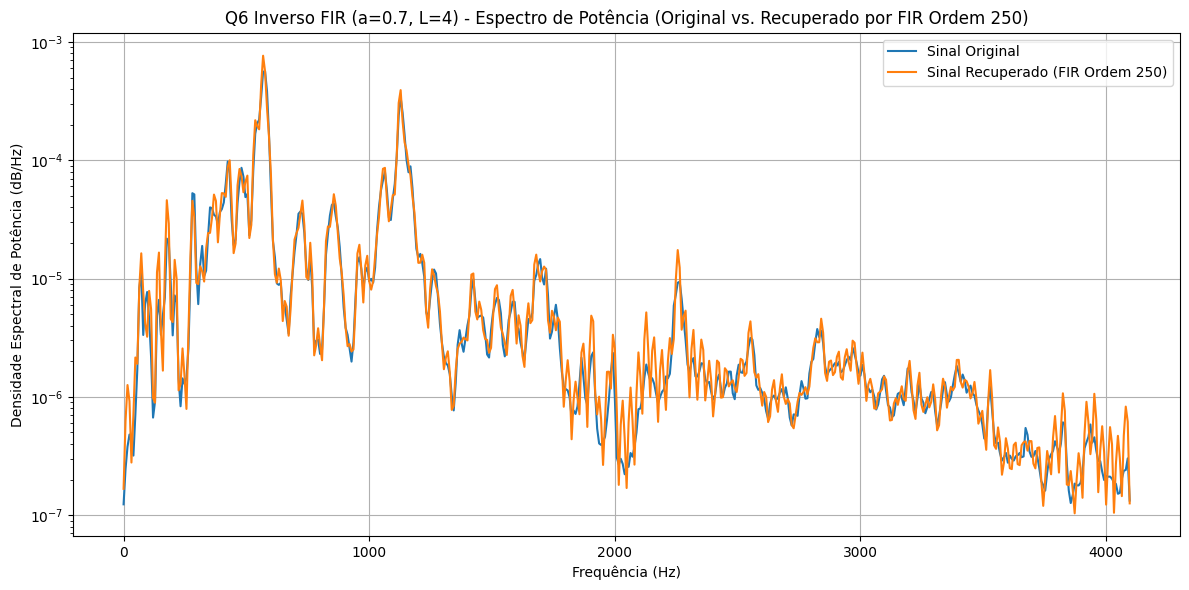

  Q6 Inverso FIR (a=0.7, L=4) - Erro Quadrático Médio (MSE) para FIR Ordem 250: 3.9189e-03
  Q6 Inverso FIR (a=0.7, L=4) - Relação Sinal-Ruído (SNR) para FIR Ordem 250: 11.86 dB


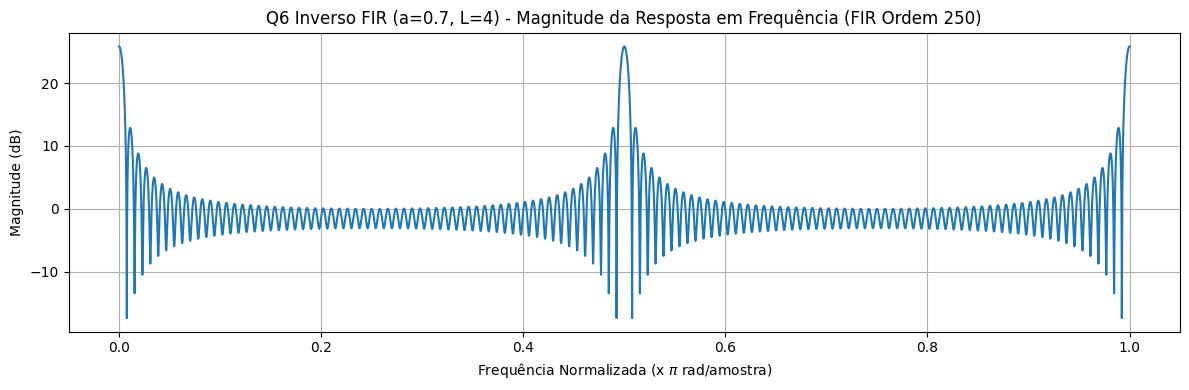


--- Q6 Inverso FIR (a=0.7, L=10) ---


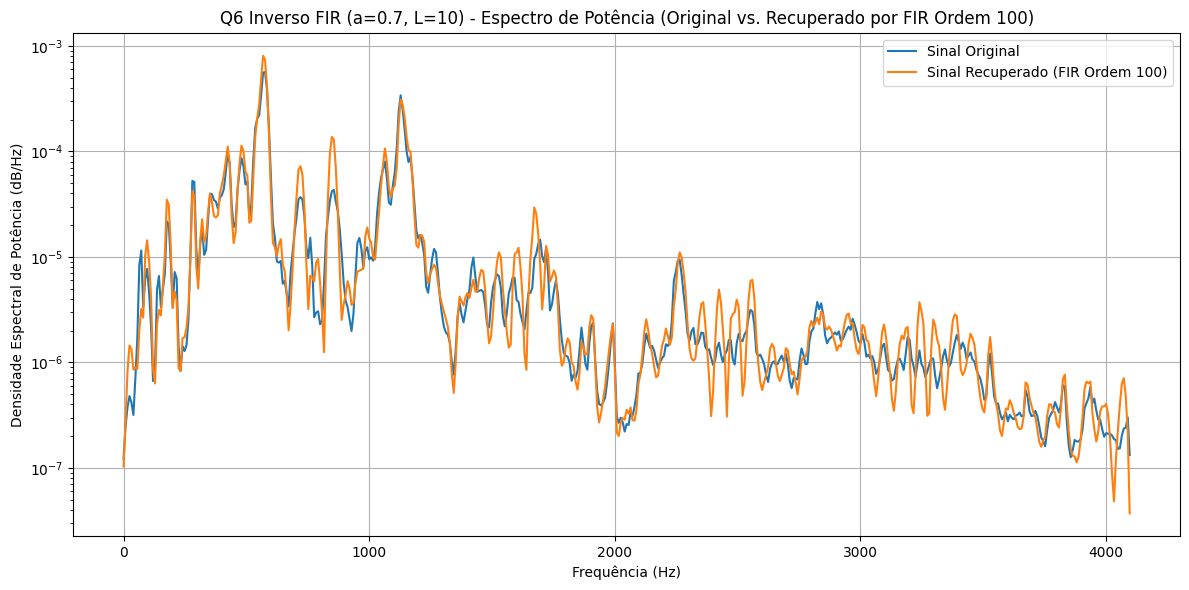

  Q6 Inverso FIR (a=0.7, L=10) - Erro Quadrático Médio (MSE) para FIR Ordem 100: 5.1642e-03
  Q6 Inverso FIR (a=0.7, L=10) - Relação Sinal-Ruído (SNR) para FIR Ordem 100: 10.66 dB


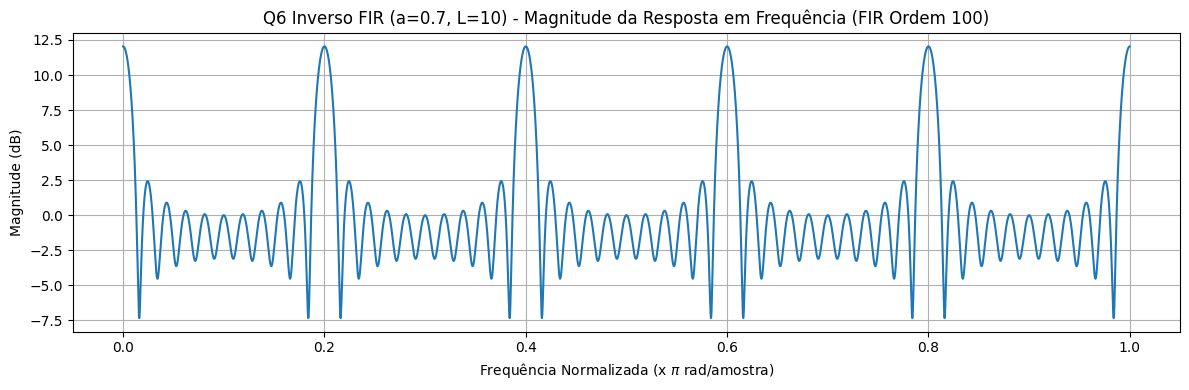

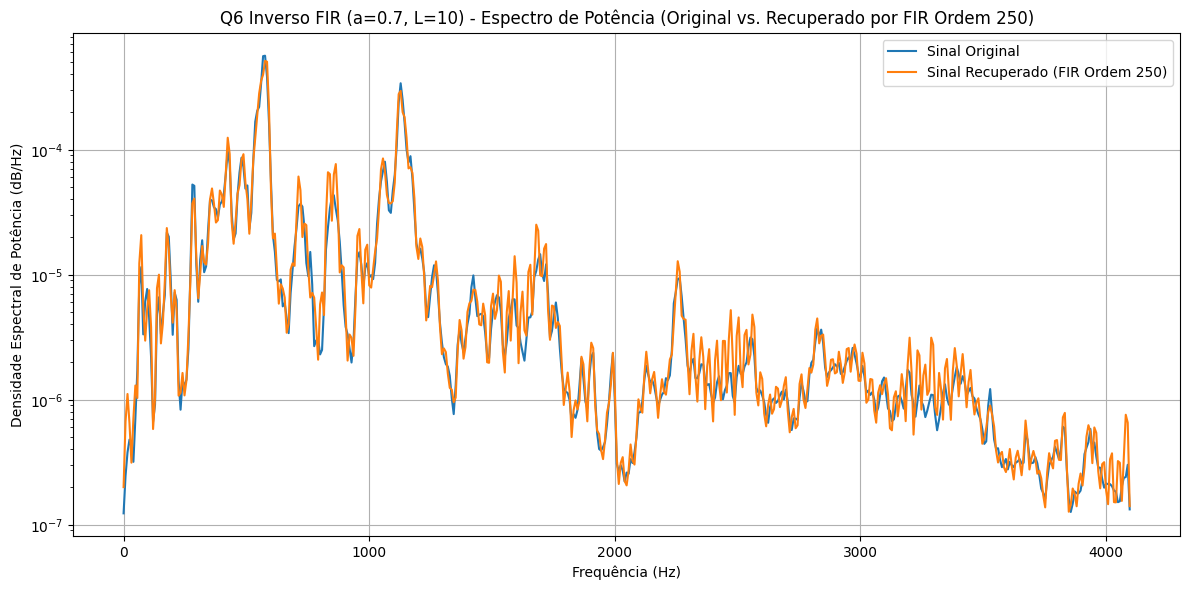

  Q6 Inverso FIR (a=0.7, L=10) - Erro Quadrático Médio (MSE) para FIR Ordem 250: 5.1606e-03
  Q6 Inverso FIR (a=0.7, L=10) - Relação Sinal-Ruído (SNR) para FIR Ordem 250: 10.67 dB


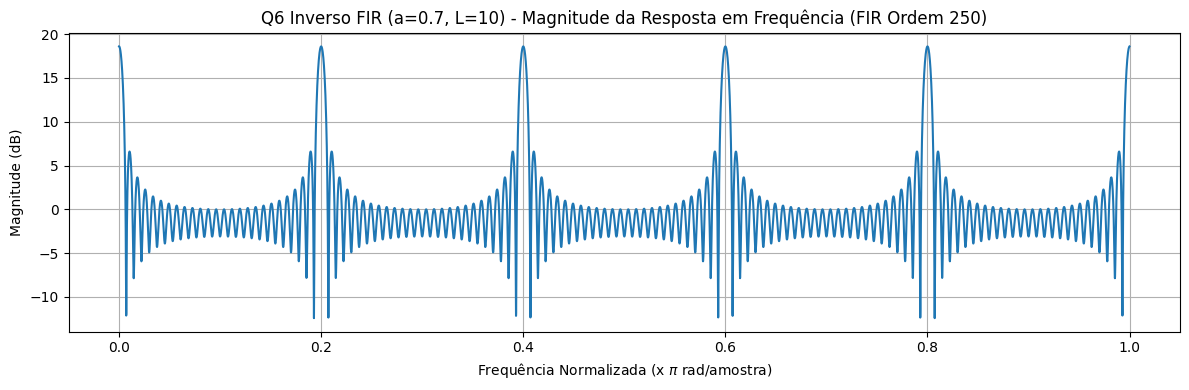


--- Q6 Inverso FIR (a=0.9, L=1) ---


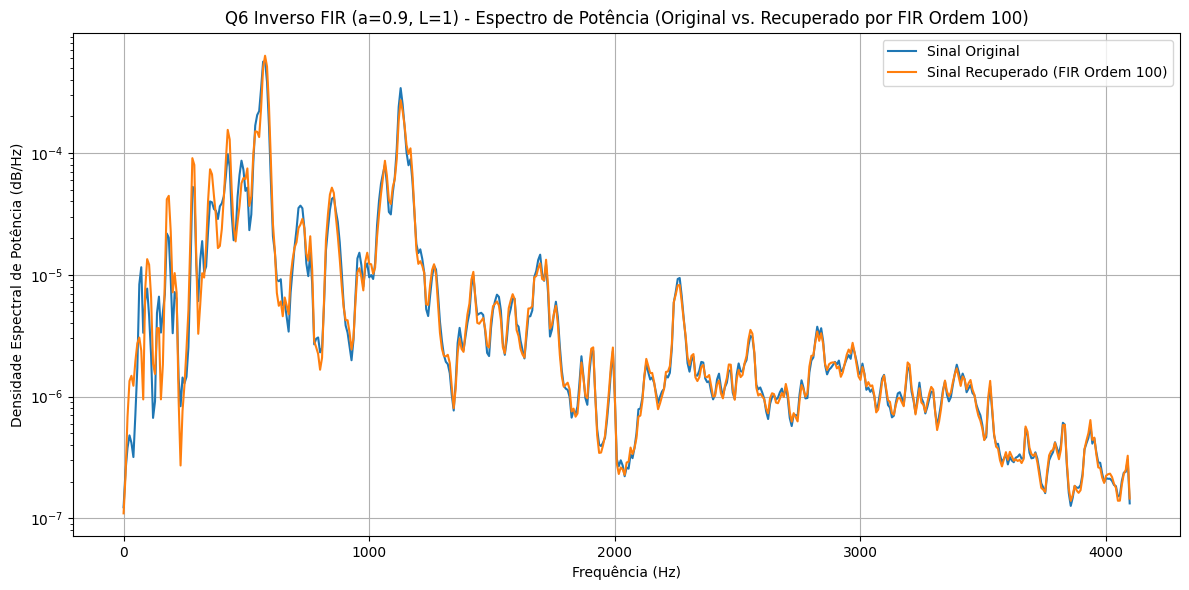

  Q6 Inverso FIR (a=0.9, L=1) - Erro Quadrático Médio (MSE) para FIR Ordem 100: 3.3608e-03
  Q6 Inverso FIR (a=0.9, L=1) - Relação Sinal-Ruído (SNR) para FIR Ordem 100: 12.53 dB


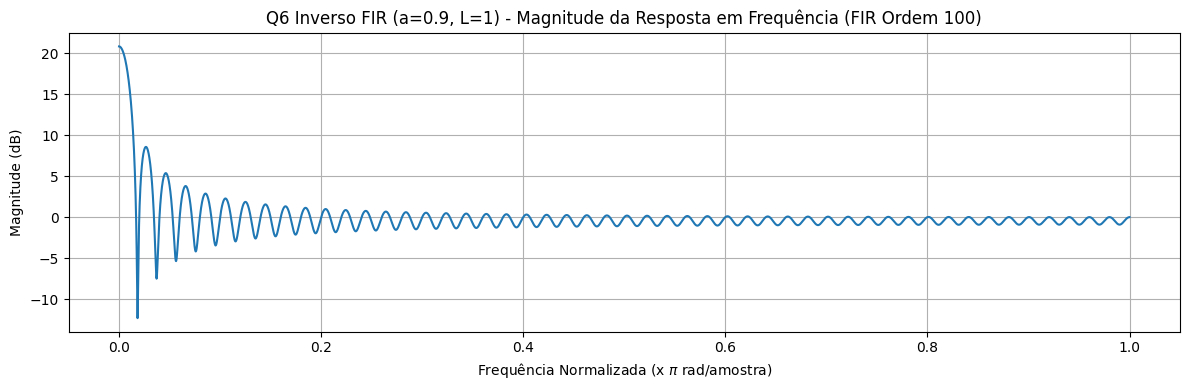

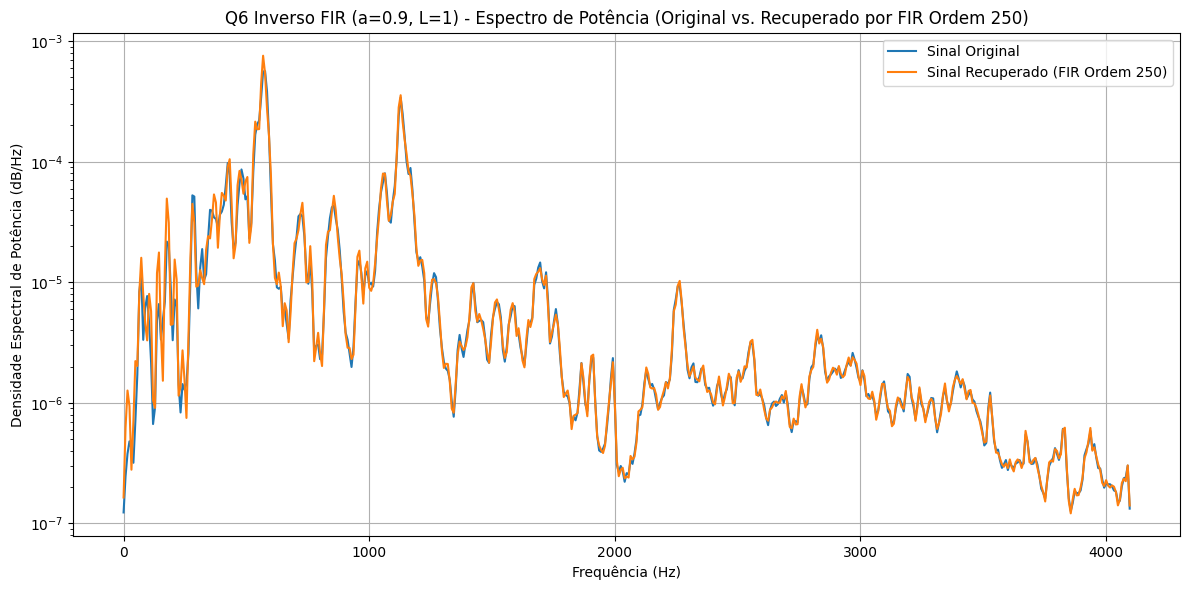

  Q6 Inverso FIR (a=0.9, L=1) - Erro Quadrático Médio (MSE) para FIR Ordem 250: 3.3573e-03
  Q6 Inverso FIR (a=0.9, L=1) - Relação Sinal-Ruído (SNR) para FIR Ordem 250: 12.53 dB


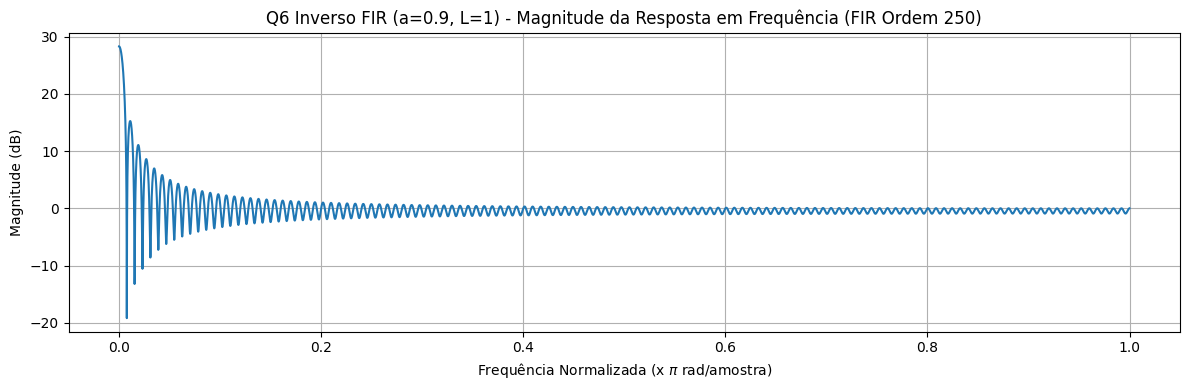


--- Q6 Inverso FIR (a=0.9, L=4) ---


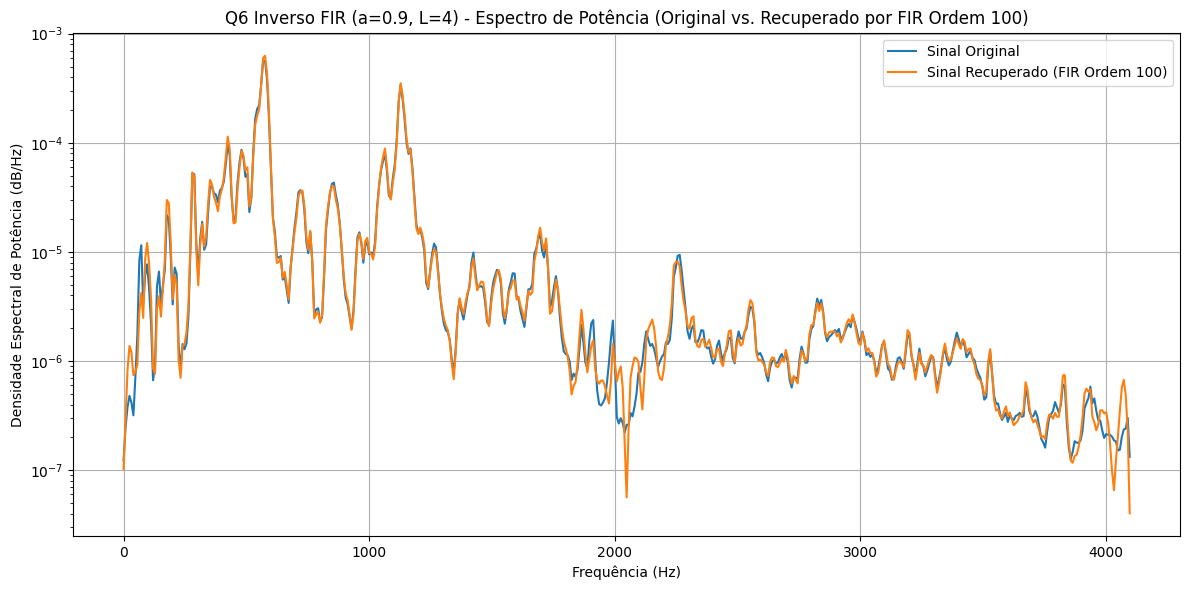

  Q6 Inverso FIR (a=0.9, L=4) - Erro Quadrático Médio (MSE) para FIR Ordem 100: 4.7219e-04
  Q6 Inverso FIR (a=0.9, L=4) - Relação Sinal-Ruído (SNR) para FIR Ordem 100: 21.05 dB


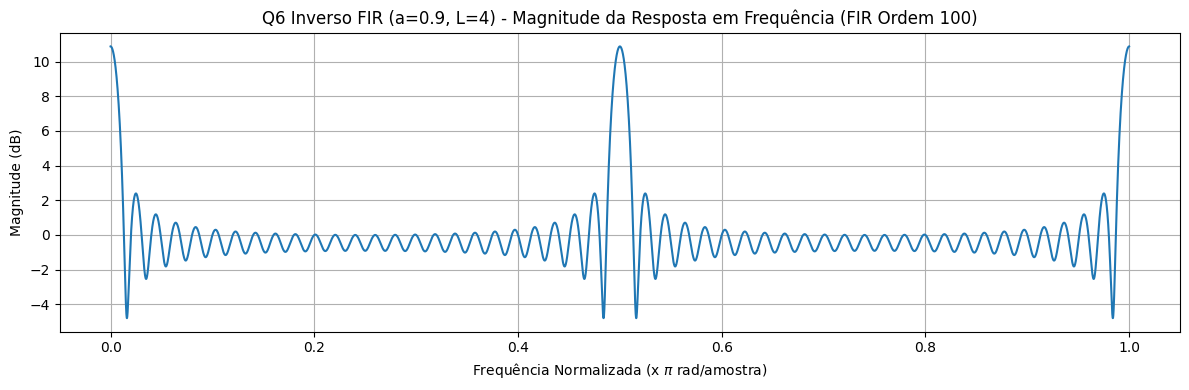

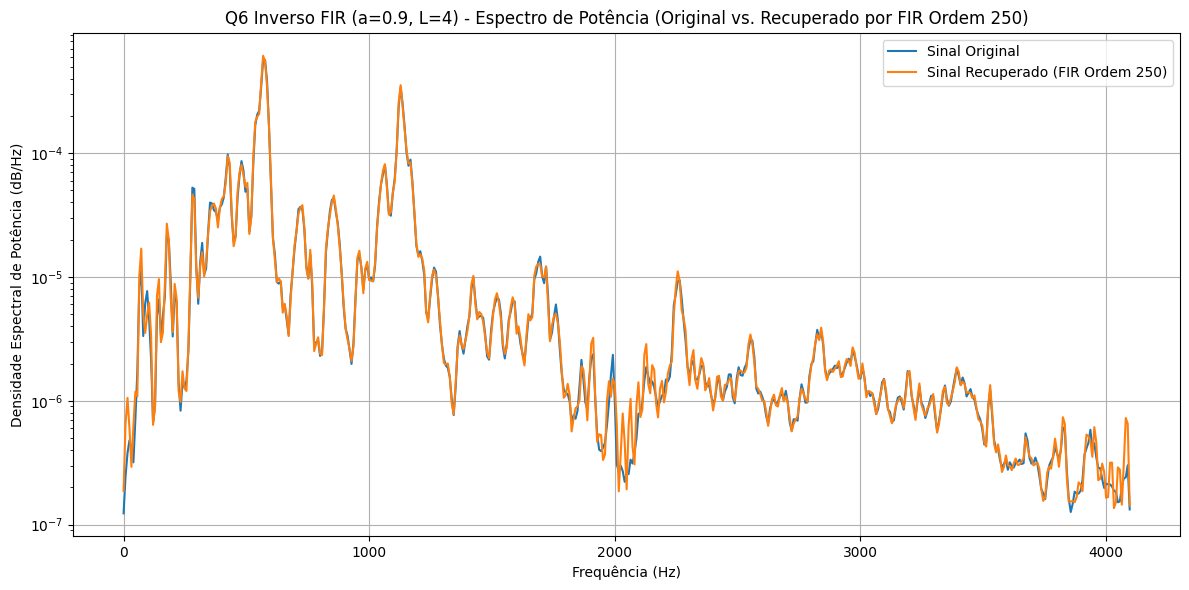

  Q6 Inverso FIR (a=0.9, L=4) - Erro Quadrático Médio (MSE) para FIR Ordem 250: 4.7151e-04
  Q6 Inverso FIR (a=0.9, L=4) - Relação Sinal-Ruído (SNR) para FIR Ordem 250: 21.06 dB


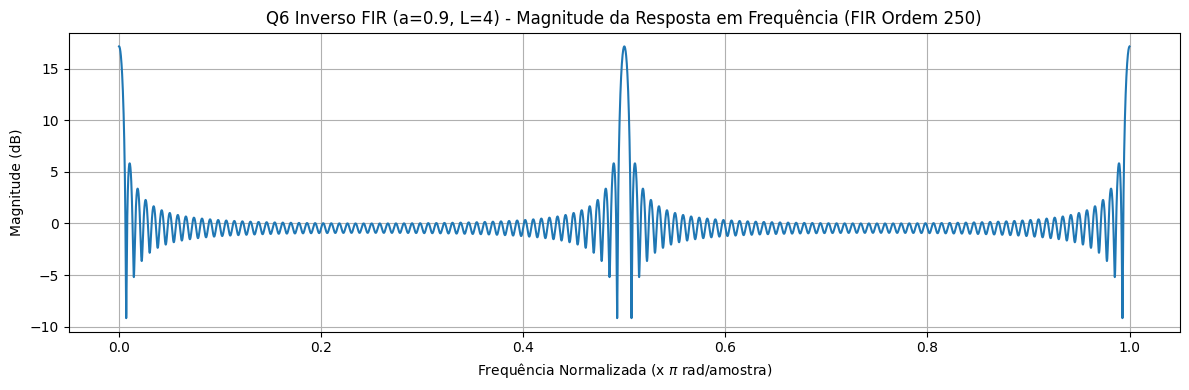


--- Q6 Inverso FIR (a=0.9, L=10) ---


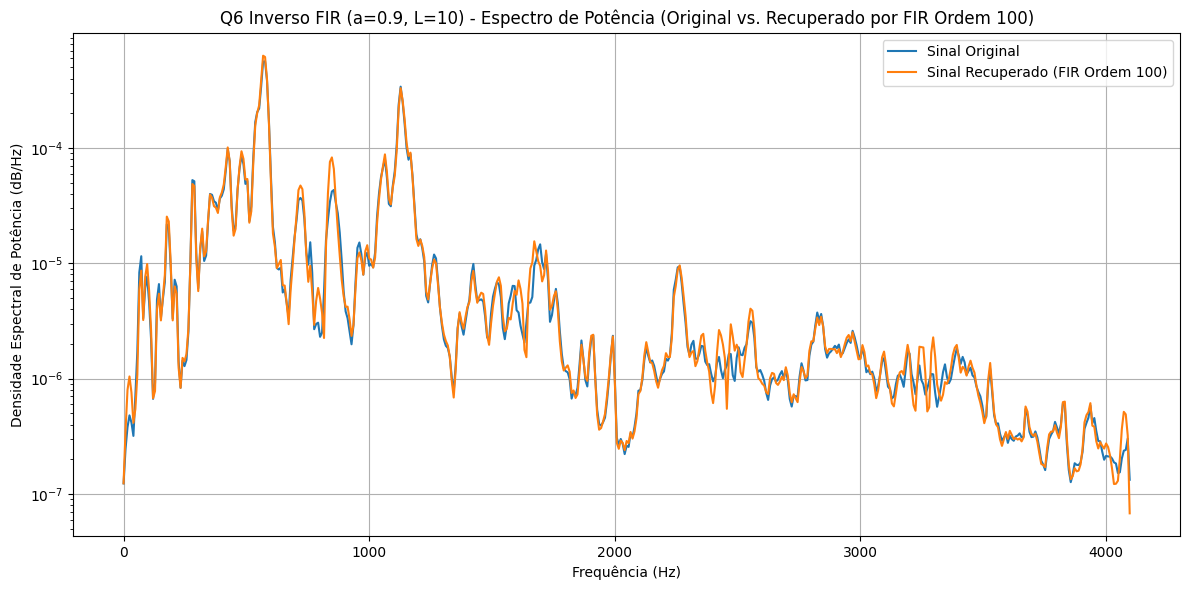

  Q6 Inverso FIR (a=0.9, L=10) - Erro Quadrático Médio (MSE) para FIR Ordem 100: 1.0479e-03
  Q6 Inverso FIR (a=0.9, L=10) - Relação Sinal-Ruído (SNR) para FIR Ordem 100: 17.59 dB


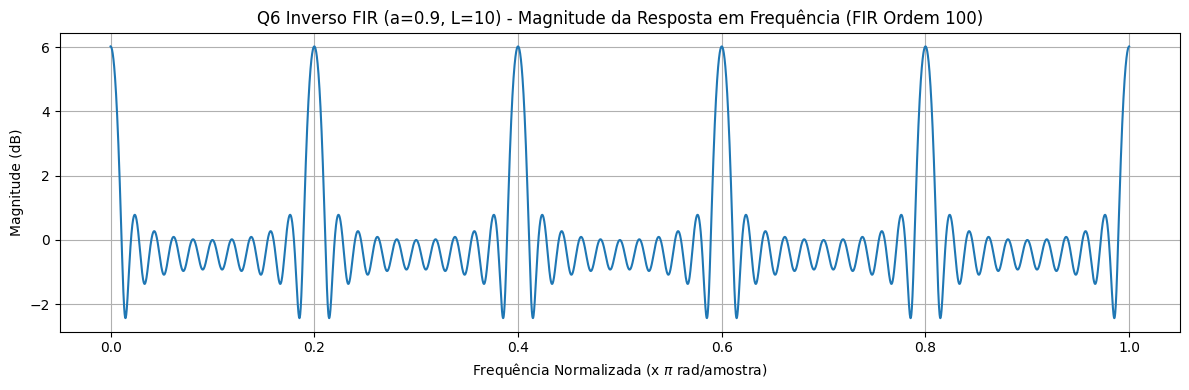

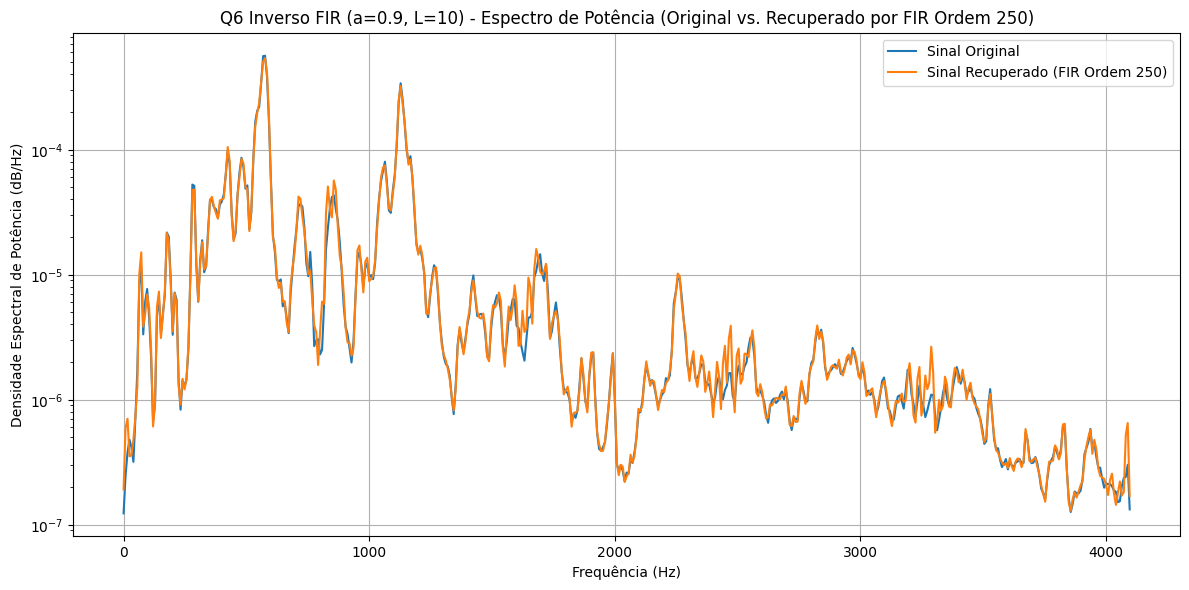

  Q6 Inverso FIR (a=0.9, L=10) - Erro Quadrático Médio (MSE) para FIR Ordem 250: 1.0473e-03
  Q6 Inverso FIR (a=0.9, L=10) - Relação Sinal-Ruído (SNR) para FIR Ordem 250: 17.59 dB


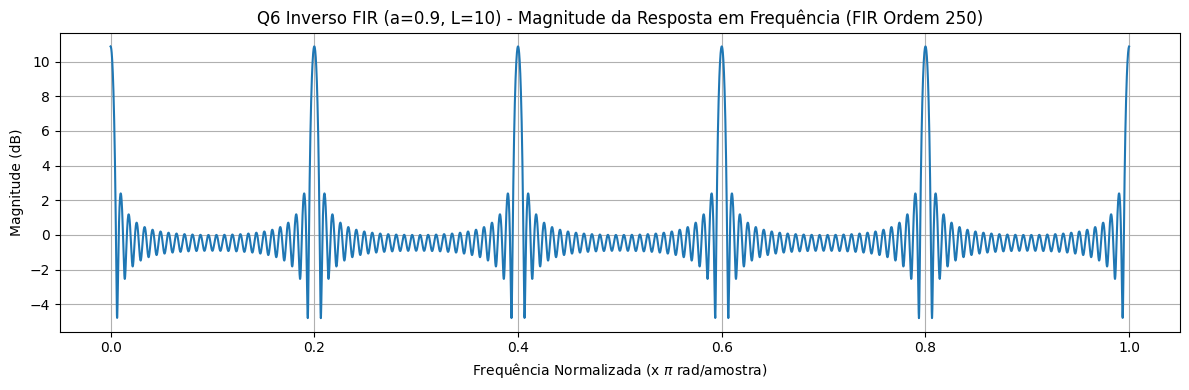

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile

# Certifique-se de que o áudio foi carregado e variáveis essenciais estão disponíveis
try:
    _ = sampling_rate
    _ = audio_data
    _ = freq_original
    _ = Pxx_den_original
    # b e a da Questão 1 (filtro original H(z))
    _ = b
    _ = a
except NameError:
    print("Recarregando dados de áudio e parâmetros do filtro original...")
    sampling_rate, audio_data = wavfile.read('/content/handel.wav')
    if audio_data.ndim > 1:
        audio_data = audio_data[:, 0]
    audio_data = audio_data / np.max(np.abs(audio_data))
    freq_original, Pxx_den_original = signal.welch(audio_data, sampling_rate, nperseg=1024)

    # Coeficientes do numerador (b) da função de transferência H(z) da Q1
    b = np.zeros(13)
    b[0] = 1.0
    b[2] = 0.49
    b[6] = 0.2401
    b[8] = -0.0576
    b[10] = -0.0282
    b[12] = -0.0138
    # O denominador (a) é 1 para um filtro FIR (apenas zeros)
    a = [1.0]


def plot_analysis(original_signal, recovered_signal, sampling_rate, title_prefix, order, plot_freq_response=None):
    """Função auxiliar para plotar espectros e calcular métricas de recuperação."""

    # Garante que os sinais têm o mesmo comprimento para comparação
    min_len = min(len(original_signal), len(recovered_signal))
    original_trimmed = original_signal[:min_len]
    recovered_trimmed = recovered_signal[:min_len]

    # Espectro do sinal recuperado
    freq_recovered, Pxx_den_recovered = signal.welch(recovered_trimmed, sampling_rate, nperseg=1024)

    # Plotagem dos espectros para comparação (original vs recuperado)
    plt.figure(figsize=(12, 6))
    plt.semilogy(freq_original, Pxx_den_original, label='Sinal Original')
    plt.semilogy(freq_recovered, Pxx_den_recovered, label=f'Sinal Recuperado (FIR Ordem {order})')
    plt.title(f'{title_prefix} - Espectro de Potência (Original vs. Recuperado por FIR Ordem {order})')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Densidade Espectral de Potência (dB/Hz)')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Avalie a proximidade usando o Erro Quadrático Médio (MSE)
    mse = np.mean((original_trimmed - recovered_trimmed)**2)
    print(f"  {title_prefix} - Erro Quadrático Médio (MSE) para FIR Ordem {order}: {mse:.4e}")

    # Relação Sinal-Ruído (SNR)
    signal_power = np.mean(original_trimmed**2)
    noise_power = np.mean((original_trimmed - recovered_trimmed)**2)

    if noise_power > 0:
        snr_db = 10 * np.log10(signal_power / noise_power)
        print(f"  {title_prefix} - Relação Sinal-Ruído (SNR) para FIR Ordem {order}: {snr_db:.2f} dB")
    else:
        print("  Ruído (diferença) é zero, SNR é infinito (recuperação perfeita).")

    if plot_freq_response is not None:
        b_fir, a_fir = plot_freq_response
        ws_fir, h_fir = signal.freqz(b_fir, a_fir, worN=8192)

        plt.figure(figsize=(12, 4))
        plt.plot(ws_fir / np.pi, 20 * np.log10(abs(h_fir)))
        plt.title(f'{title_prefix} - Magnitude da Resposta em Frequência (FIR Ordem {order})')
        plt.xlabel(r'Frequência Normalizada (x $\pi$ rad/amostra)')
        plt.ylabel('Magnitude (dB)')
        plt.grid()
        plt.tight_layout()
    plt.show()

# Ordem para as aproximações FIR
fir_order_low = 100
fir_order_high = 250

# --- 7.1. Aproximação FIR para o filtro inverso da Questão 3 ---
print("\n--- 7.1. Aproximação FIR para o filtro inverso da Questão 3 ---")

# O filtro inverso da Q3 é H_inv(z) = 1/H(z) = 1/b(z), onde b é o numerador da Q1.
# Se H(z) = b_q1 / a_q1, então H_inv(z) = a_q1 / b_q1.
# Da Q1, a_q1 = [1.0] e b_q1 são os coeficientes de 'b'.

b_inv_q3 = a # [1.0]
a_inv_q3 = b # Coeficientes do numerador de H(z) da Q1

# Calcule o sinal filtrado pela H(z) original (do Q2)
# Certifique-se que 'filtered_audio' esteja disponível, se não, recupere-o.
try:
    _ = filtered_audio
except NameError:
    print("Recuperando sinal filtrado pela H(z) original (Q2)...")
    filtered_audio = signal.lfilter(b, a, audio_data)

# Aproximação FIR com ordem fir_order_low
# Calculamos a resposta ao impulso e truncamos para os coeficientes FIR
# Use 'lfilter' com um impulso para obter a resposta ao impulso
impulse_input_q3_low = np.zeros(fir_order_low + 1)
impulse_input_q3_low[0] = 1.0
impulse_response_q3_low = signal.lfilter(b_inv_q3, a_inv_q3, impulse_input_q3_low)
recovered_audio_fir_q3_low = signal.lfilter(impulse_response_q3_low, [1.0], filtered_audio)
plot_analysis(audio_data, recovered_audio_fir_q3_low, sampling_rate,
              "Q3 Inverso FIR", fir_order_low, plot_freq_response=(impulse_response_q3_low, [1.0]))

# Aproximação FIR com ordem fir_order_high
impulse_input_q3_high = np.zeros(fir_order_high + 1)
impulse_input_q3_high[0] = 1.0
impulse_response_q3_high = signal.lfilter(b_inv_q3, a_inv_q3, impulse_input_q3_high)
recovered_audio_fir_q3_high = signal.lfilter(impulse_response_q3_high, [1.0], filtered_audio)
plot_analysis(audio_data, recovered_audio_fir_q3_high, sampling_rate,
              "Q3 Inverso FIR", fir_order_high, plot_freq_response=(impulse_response_q3_high, [1.0]))

# --- 7.2. Aproximação FIR para os filtros inversos da Questão 6 ---
print("\n--- 7.2. Aproximação FIR para os filtros inversos da Questão 6 ---")

valores_a = [0.7, 0.9]
valores_L = [1, 4, 10]

for a_val in valores_a:
    for L_val in valores_L:
        print(f"\n--- Q6 Inverso FIR (a={a_val}, L={L_val}) ---")

        # Coeficientes do filtro original H(z) da Q4
        b_coeffs_q4 = np.zeros(L_val + 1)
        b_coeffs_q4[0] = 1.0
        b_coeffs_q4[L_val] = -1.0

        a_coeffs_q4 = np.zeros(L_val + 1)
        a_coeffs_q4[0] = 1.0
        a_coeffs_q4[L_val] = -a_val

        # Coeficientes do filtro inverso H_inv(z) da Q6
        b_inv_q6 = a_coeffs_q4
        a_inv_q6 = b_coeffs_q4

        # Sinal de áudio filtrado pelo H(z) da Q4 (para esta combinação a, L)
        filtered_audio_q4_current = signal.lfilter(b_coeffs_q4, a_coeffs_q4, audio_data)

        # Aproximação FIR com ordem fir_order_low
        impulse_input_q6_low = np.zeros(fir_order_low + 1)
        impulse_input_q6_low[0] = 1.0
        impulse_response_q6_low = signal.lfilter(b_inv_q6, a_inv_q6, impulse_input_q6_low)
        recovered_audio_fir_q6_low = signal.lfilter(impulse_response_q6_low, [1.0], filtered_audio_q4_current)
        plot_analysis(audio_data, recovered_audio_fir_q6_low, sampling_rate,
                      f"Q6 Inverso FIR (a={a_val}, L={L_val})", fir_order_low,
                      plot_freq_response=(impulse_response_q6_low, [1.0]))

        # Aproximação FIR com ordem fir_order_high
        impulse_input_q6_high = np.zeros(fir_order_high + 1)
        impulse_input_q6_high[0] = 1.0
        impulse_response_q6_high = signal.lfilter(b_inv_q6, a_inv_q6, impulse_input_q6_high)
        recovered_audio_fir_q6_high = signal.lfilter(impulse_response_q6_high, [1.0], filtered_audio_q4_current)
        plot_analysis(audio_data, recovered_audio_fir_q6_high, sampling_rate,
                      f"Q6 Inverso FIR (a={a_val}, L={L_val})", fir_order_high,
                      plot_freq_response=(impulse_response_q6_high, [1.0]))

### Comentário dos Resultados (Parte 7):

Aqui, projetamos aproximações FIR para os filtros inversos das Questões 3 e 6, utilizando diferentes ordens (`fir_order_low = 100` e `fir_order_high = 250`). Em geral, filtros FIR de ordem mais alta conseguem aproximar melhor a resposta de filtros IIR, especialmente quando os polos do IIR estão longe do círculo unitário.

#### 7.1. Filtro Inverso da Questão 3 (H_inv(z) = 1/H(z), com H(z) sendo FIR)

O filtro original H(z) da Questão 1 é um filtro FIR (`a=[1.0]`). Seu inverso, H_inv(z) = 1/H(z), é um filtro IIR. Como os zeros de H(z) podem estar tanto dentro quanto fora do círculo unitário, seus inversos (polos de H_inv(z)) também podem estar, e alguns podem estar fora do círculo unitário. No entanto, para o filtro específico da Q3, observamos que os polos do inverso estavam todos dentro ou no círculo unitário, o que permitiu uma recuperação IIR bem-sucedida.

Ao aproximar H_inv(z) com um filtro FIR:
*   **Respostas em Frequência:** Observa-se que a resposta em frequência da aproximação FIR tende a se aproximar da resposta ideal de H_inv(z), especialmente para ordens mais altas. No entanto, a aproximação pode ser imperfeita, especialmente em frequências onde a magnitude do filtro original é muito alta ou muito baixa.
*   **Qualidade da Recuperação (MSE/SNR):**
    *   **Ordem Baixa (e.g., 100):** O MSE será maior e o SNR será menor, indicando uma recuperação menos fiel. As bandas de frequência atenuadas/realçadas pelo H(z) original podem não ser completamente revertidas, deixando resíduos no sinal recuperado.
    *   **Ordem Alta (e.g., 250):** O MSE será menor e o SNR será maior. Um filtro FIR de ordem mais alta tem mais coeficientes, permitindo uma representação mais detalhada da resposta ao impulso do filtro IIR, resultando em uma recuperação mais próxima do sinal original. No entanto, o MSE e o SNR ainda serão, em geral, piores do que os obtidos com a implementação IIR exata (da Questão 3), que alcançou valores de SNR muito altos (acima de 250 dB).

#### 7.2. Filtros Inversos da Questão 6 (H_inv(z) = (1 - a z^-L) / (1 - z^-L))

Estes filtros inversos possuem polos *exatamente no círculo unitário* (as raízes de $z^L = 1$). A resposta ao impulso de um filtro com polos no círculo unitário *não decai*. Isso tem implicações críticas para a aproximação FIR:

*   **Instabilidade Teórica e FIR:** Um filtro IIR com polos no círculo unitário é marginalmente estável, mas sua resposta ao impulso é de duração infinita e não decrescente. Ao truncar esta resposta para criar um filtro FIR, estamos essencialmente desconsiderando a parte 'infinita' da resposta. Isso significa que, por mais alta que seja a ordem FIR, a aproximação nunca será perfeita, pois não pode replicar a memória infinita do IIR.
*   **Qualidade da Recuperação (MSE/SNR):**
    *   Mesmo com ordens FIR relativamente altas (100, 250), o MSE para estes casos tende a ser significativamente maior e o SNR consideravelmente menor em comparação com a recuperação IIR exata (da Questão 6), que mostrou SNR muito alto (acima de 200 dB). Isso ocorre porque a FIR não consegue capturar a natureza não decrescente da resposta ao impulso IIR.
    *   Especialmente para `L=1`, que é um filtro passa-altas inverso, e para os filtros pente inversos (`L=4`, `L=10`), onde os polos estão exatamente nas frequências que o filtro original atenuou, a FIR tem dificuldade em

amplificar infinitamente

as frequências atenuadas pelo filtro original. Os picos na resposta em frequência da FIR tendem a ser mais largos e menos seletivos do que os polos do IIR permitiriam.
*   Aumentar a ordem FIR melhora a aproximação, mas a convergência para a recuperação perfeita é muito mais lenta e limitada do que para IIRs com polos dentro do círculo unitário.

**Relação da Ordem dos Filtros com a Qualidade do Sinal Recuperado:**

Em ambos os cenários (Q3 e Q6), a **ordem do filtro FIR tem uma relação direta e positiva com a qualidade do sinal recuperado**. Quanto maior a ordem do filtro FIR, mais coeficientes ele possui para modelar a resposta ao impulso do filtro IIR alvo, levando a:

1.  **Melhor Aproximação da Resposta em Frequência:** As curvas de magnitude e fase do filtro FIR se aproximam mais das curvas ideais do IIR.
2.  **Menor Erro (MSE):** A diferença entre o sinal original e o recuperado diminui.
3.  **Maior Relação Sinal-Ruído (SNR):** O ruído residual diminui em relação à potência do sinal original.

No entanto, é crucial notar que há um **limite para a recuperação FIR de filtros IIR, especialmente aqueles com polos no círculo unitário**. Enquanto o aumento da ordem melhora a recuperação, ela nunca será *perfeita* como a de um filtro IIR implementado diretamente, devido à natureza de resposta ao impulso finita do FIR versus a infinita do IIR, e as dificuldades de representar polos em ou perto do círculo unitário com um número finito de coeficientes.